# ✈️ Airline Operations Analytics — Exploratory Data Analysis (EDA)

## Objective
This notebook performs a structured, business-focused EDA of airline operations data.

The analysis is organized into:
1. Data understanding and quality checks
2. Univariate analysis
3. Bivariate analysis
4. Multivariate analysis
5. Operational performance analysis
6. Cancellation and diversion analysis
7. Weather impact analysis
8. KPI tables and business-question validation
9. Executive-level interpretation framework

### Key business questions
- What causes flight delays?
- Which airlines, airports, routes, and time periods show higher operational issues?
- How do cancellations and diversions vary across the network?
- Does weather materially affect delays, cancellations, and diversions?
- Which operational relationships are strongest?

## 1. Import libraries and configure the analysis environment

In [1]:
# Core data-analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display and plotting configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

## 2. Load the cleaned dataset

In [2]:
# Load the processed airline dataset.
# Update this path if the project is moved to another machine.
file_path = r"D:\Data Analyst\EXCEL\airline-operations-intelligence\Airline-Operations-Intelligence\data\processed\flights_2026_q1.csv"

df = pd.read_csv(file_path)
print("Data loaded successfully")

C:\Users\bhupa\AppData\Local\Temp\ipykernel_20232\1522411002.py:5: DtypeWarning: Columns (60,66) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Data loaded successfully


In [3]:
# Confirm the dataset dimensions before starting the analysis.
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1847242
Columns: 78


In [4]:
# Preview the first few records to understand the raw structure.
df.head()

,year,quarter,month,day_of_month,day_of_week,fl_date,mkt_unique_carrier,branded_code_share,mkt_carrier_airline_id,mkt_carrier,mkt_carrier_fl_num,origin,origin_city_name,origin_state_abr,origin_state_nm,dest,dest_city_name,dest_state_abr,dest_state_nm,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,taxi_out,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,flight_status,dep_time_at_cancellation,missing_operational_duration,extreme_dep_delay,extreme_arr_delay,is_cancelled,is_diverted,is_irregular_operation,is_departure_delayed,is_arrival_delayed,severe_departure_delay,severe_arrival_delay,origin_airport_name,origin_city,origin_country,origin_latitude,origin_longitude,origin_timezone,dest_airport_name,dest_city,dest_country,dest_latitude,dest_longitude,dest_timezone,dep_hour,dep_minute,scheduled_departure,departure_hour,temperature,precipitation,wind_speed,weather_code,weather_matched,weather_category,bad_weather
0,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1,JFK,"New York, NY",NY,New York,LAX,"Los Angeles, CA",CA,California,700,657.0,-3.0,0.0,0.0,67.0,11.0,1021,1104.0,43.0,43.0,1.0,0.0,NaN,0.0,381.0,427.0,349.0,2475.0,0.0,0.0,43.0,0.0,0.0,COMPLETED,NaN,False,False,False,0,0,0,0,1,0,0,John F Kennedy International Airport,New York,United States,40.639801,-73.778900,-5,Los Angeles International Airport,Los Angeles,United States,33.942501,-118.407997,-8,7,0,2026-01-01 07:00:00,7,0.9,0.0,18.3,3,True,Cloudy,0
1,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,10,LAX,"Los Angeles, CA",CA,California,JFK,"New York, NY",NY,New York,2130,2128.0,-2.0,0.0,0.0,16.0,6.0,551,520.0,-31.0,0.0,0.0,0.0,NaN,0.0,321.0,292.0,270.0,2475.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0,Los Angeles International Airport,Los Angeles,United States,33.942501,-118.407997,-8,John F Kennedy International Airport,New York,United States,40.639801,-73.778900,-5,21,30,2026-01-01 21:30:00,21,17.3,0.2,4.5,51,True,Rain,1
2,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1002,MIA,"Miami, FL",FL,Florida,MSY,"New Orleans, LA",LA,Louisiana,2245,2252.0,7.0,7.0,0.0,16.0,3.0,2359,2356.0,-3.0,0.0,0.0,0.0,NaN,0.0,134.0,124.0,105.0,674.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0,Miami International Airport,Miami,United States,25.793200,-80.290604,-5,Louis Armstrong New Orleans International Airport,New Orleans,United States,29.993401,-90.258003,-6,22,45,2026-01-01 22:45:00,22,18.2,0.0,7.9,0,True,Clear,0
3,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1003,DEN,"Denver, CO",CO,Colorado,MIA,"Miami, FL",FL,Florida,2338,2338.0,0.0,0.0,0.0,13.0,6.0,527,508.0,-19.0,0.0,0.0,0.0,NaN,0.0,229.0,210.0,191.0,1709.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0,Denver International Airport,Denver,United States,39.861698,-104.672997,-7,Miami International Airport,Miami,United States,25.793200,-80.290604,-5,23,38,2026-01-01 23:38:00,23,12.5,0.0,4.8,2,True,Cloudy,0
4,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1004,BOS,"Boston, MA",MA,Massachusetts,CLT,"Charlotte, NC",NC,North Carolina,757,756.0,-1.0,0.0,0.0,26.0,4.0,1030,1023.0,-7.0,0.0,0.0,0.0,NaN,0.0,153.0,147.0,117.0,728.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0,General Edward Lawrence Logan International Ai...,Boston,United States,42.364300,-71.005203,-5,Charlotte Douglas International Airport,Charlotte,United States,35.214001,-80.943100,-5,7,57,2026-01-01 07:57:00,7,-2.4,0.1,16.7,71,True,Snow,1


## 3. Data understanding and quality checks

In [5]:
# Review column names, data types, and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1847242 entries, 0 to 1847241
Data columns (total 78 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   year                          int64  
 1   quarter                       int64  
 2   month                         int64  
 3   day_of_month                  int64  
 4   day_of_week                   int64  
 5   fl_date                       object 
 6   mkt_unique_carrier            object 
 7   branded_code_share            object 
 8   mkt_carrier_airline_id        int64  
 9   mkt_carrier                   object 
 10  mkt_carrier_fl_num            int64  
 11  origin                        object 
 12  origin_city_name              object 
 13  origin_state_abr              object 
 14  origin_state_nm               object 
 15  dest                          object 
 16  dest_city_name                object 
 17  dest_state_abr                object 
 18  dest_state_nm         

In [6]:
# Statistical summary of numeric variables.
df.describe()

,year,quarter,month,day_of_month,day_of_week,mkt_carrier_airline_id,mkt_carrier_fl_num,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,taxi_out,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,cancelled,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,dep_time_at_cancellation,is_cancelled,is_diverted,is_irregular_operation,is_departure_delayed,is_arrival_delayed,severe_departure_delay,severe_arrival_delay,origin_latitude,origin_longitude,dest_latitude,dest_longitude,dep_hour,dep_minute,departure_hour,temperature,precipitation,wind_speed,weather_code,bad_weather
count,1847242.0,1847242.0,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.784775e+06,1.786268e+06,1.786268e+06,1.786268e+06,1.785251e+06,1.784287e+06,1.847242e+06,1.783398e+06,1.780194e+06,1.780194e+06,1.780194e+06,1.847242e+06,1.847242e+06,1.847232e+06,1.780185e+06,1.780185e+06,1.847242e+06,384426.000000,384426.000000,384426.000000,384426.000000,384426.000000,1527.000000,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06
mean,2026.0,1.0,2.039273e+00,1.556970e+01,4.018039e+00,1.982750e+04,2.764304e+03,1.322166e+03,1.329527e+03,1.393807e+01,1.758626e+01,2.182478e-01,1.920085e+01,8.785626e+00,1.504609e+03,1.473538e+03,7.249089e+00,1.734560e+01,2.159461e-01,3.373191e-02,2.564364e-03,1.480705e+02,1.415679e+02,1.135985e+02,8.080800e+02,26.771269,5.317260,14.499233,0.130366,29.269703,1559.886051,3.373191e-02,2.564364e-03,3.629627e-02,2.110438e-01,2.081081e-01,7.868217e-02,7.735478e-02,3.658156e+01,-9.435438e+01,3.658183e+01,-9.435467e+01,1.295125e+01,2.704187e+01,1.295125e+01,8.185714e+00,8.715198e-02,1.074916e+01,8.346313e+00,1.200552e-01
std,0.0,0.0,8.309906e-01,8.701216e+00,2.017735e+00,2.667073e+02,1.724521e+03,4.851421e+02,5.009625e+02,6.111301e+01,5.991430e+01,4.130566e-01,1.113011e+01,7.763654e+00,5.062326e+02,5.338911e+02,6.346866e+01,5.963412e+01,4.114772e-01,1.805383e-01,5.057459e-02,7.225020e+01,7.243144e+01,7.074440e+01,5.896536e+02,82.074800,41.409899,34.940501,4.280014,64.896116,542.915105,1.805383e-01,5.057459e-02,1.870264e-01,4.080495e-01,4.059547e-01,2.692421e-01,2.671536e-01,6.044470e+00,1.823632e+01,6.044221e+00,1.823647e+01,4.816062e+00,1.829083e+01,4.816062e+00,1.060397e+01,4.880843e-01,6.577387e+00,1.869761e+01,3.250262e-01
min,2026.0,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-6.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,1.400000e+01,6.000000e+00,3.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.433100e+01,-1.766460e+02,-1.433100e+01,-1.766460e+02,0.000000e+00,0.000000e+00,0.000000e+00,-4.260000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2026.0,1.0,1.000000e+00,8.000000e+00,2.000000e+00,1.979000e+04,1.332000e+03,9.080000e+02,9.130000e+02,-7.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,5.000000e+00,1.115000e+03,1.058000e+03,-1.800000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.500000e+01,8.900000e+01,6.200000e+01,3.730000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1179.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.289680e+01,-1.066090e+02,3.289680e+01,-1.066090e+02,9.000000e+00,1.000000e+01,9.000000e+00,8.000000e-01,0.000000e+00,5.700000e+00,0.000000e+00,0.000000e+00
50%,2026.0,1.0,2.000000e+00,1.600000e+01,4.000000e+00,1.980500e+04,2.452000e+03,1.315000e+03,1.325000e+03,-2.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,7.000000e+00,1.524000e

In [7]:
# Check for exact duplicate records.
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Remove exact duplicate records only when they are present.
# This prevents duplicated observations from biasing downstream KPIs.
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed:", duplicate_count)
    print("Rows after deduplication:", len(df))
else:
    print("No exact duplicate rows found.")

Duplicate rows: 0
No exact duplicate rows found.


In [8]:
# Review the number of unique values in high-cardinality columns.
df.nunique().sort_values(ascending=False).head(20)

scheduled_departure         101457
mkt_carrier_fl_num            6582
arr_delay                     1622
dep_delay                     1581
distance                      1567
arr_delay_new                 1535
dep_delay_new                 1525
arr_time                      1439
dep_time                      1435
crs_arr_time                  1364
carrier_delay                 1321
crs_dep_time                  1266
late_aircraft_delay           1002
weather_delay                  882
dep_time_at_cancellation       821
temperature                    808
actual_elapsed_time            706
air_time                       669
nas_delay                      616
wind_speed                     530
dtype: int64

## 4. Prepare date and time dimensions

In [9]:
# Convert the flight date into a proper datetime type.
df["fl_date"] = pd.to_datetime(df["fl_date"], errors="coerce")

# Create reusable calendar dimensions for time-based analysis.
df["year"] = df["fl_date"].dt.year
df["month"] = df["fl_date"].dt.month
df["month_name"] = df["fl_date"].dt.month_name()
df["day_of_week"] = df["fl_date"].dt.day_name()

In [10]:
# Validate the available analysis period.
print("Start date:", df["fl_date"].min())
print("End date:", df["fl_date"].max())

Start date: 2026-01-01 00:00:00
End date: 2026-03-31 00:00:00


## 5. Missing-value overview

In [11]:
# Identify columns containing missing values.
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Top columns by missing-value count:")
missing.head(20)

Top columns by missing-value count:


dep_time_at_cancellation    1845715
cancellation_code           1784931
nas_delay                   1462816
late_aircraft_delay         1462816
carrier_delay               1462816
security_delay              1462816
weather_delay               1462816
actual_elapsed_time           67057
air_time                      67057
arr_del15                     67048
arr_delay                     67048
arr_delay_new                 67048
arr_time                      63844
taxi_in                       62955
dep_time                      62467
taxi_out                      61991
dep_del15                     60974
dep_delay_new                 60974
dep_delay                     60974
crs_elapsed_time                 10
dtype: int64

In [12]:
# Calculate the percentage of missing values for each column.
missing_pct = (df.isna().mean() * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Top columns by missing-value percentage:")
missing_pct.head(20)

Top columns by missing-value percentage:


dep_time_at_cancellation    99.92
cancellation_code           96.63
late_aircraft_delay         79.19
carrier_delay               79.19
security_delay              79.19
weather_delay               79.19
nas_delay                   79.19
arr_delay_new                3.63
arr_delay                    3.63
actual_elapsed_time          3.63
arr_del15                    3.63
air_time                     3.63
arr_time                     3.46
taxi_in                      3.41
dep_time                     3.38
taxi_out                     3.36
dep_delay                    3.30
dep_delay_new                3.30
dep_del15                    3.30
dtype: float64

# 6. Univariate Analysis

Univariate analysis examines one variable at a time.  
The objective is to understand distributions, frequencies, central tendency, spread, and unusual values before studying relationships between variables.

## 6.1 Flight status distribution

In [13]:
# Frequency of each operational flight status.
status_counts = df["flight_status"].value_counts()
status_counts

flight_status
COMPLETED    1780194
CANCELLED      62311
DIVERTED        4737
Name: count, dtype: int64

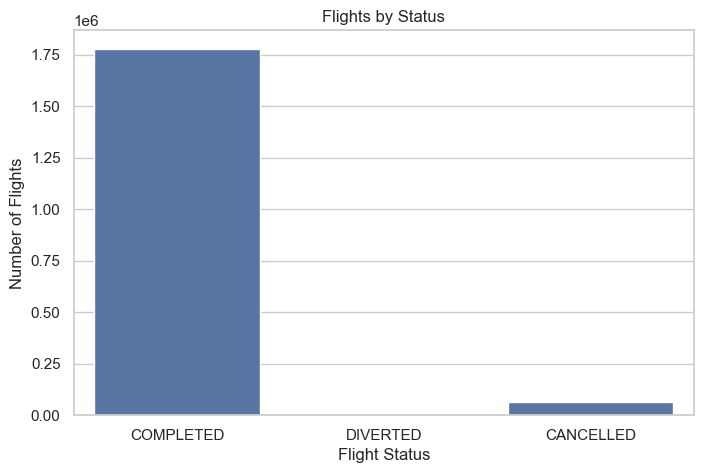

In [14]:
# Count plot for absolute flight volumes by status.
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="flight_status")
plt.title("Flights by Status")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.show()

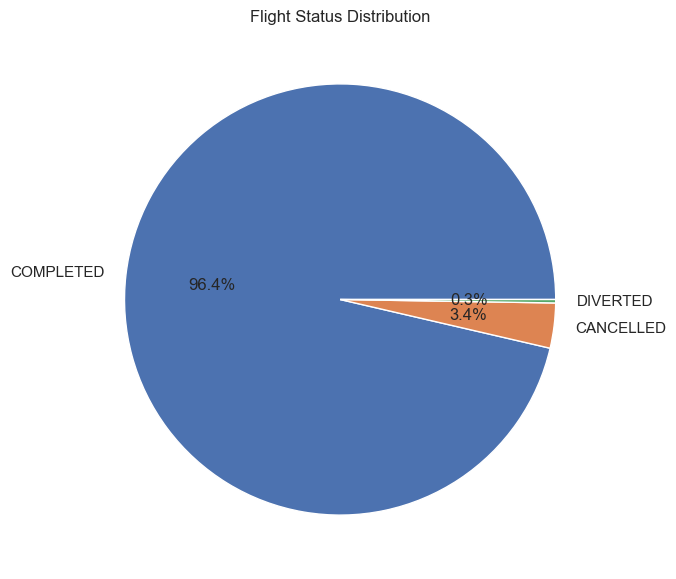

In [15]:
# Proportional view of flight statuses.
status_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7))
plt.title("Flight Status Distribution")
plt.ylabel("")
plt.show()

## 6.2 Core operational KPIs

In [16]:
# Calculate portfolio-level operational KPIs.
total_flights = len(df)
completed_flights = (df["flight_status"] == "COMPLETED").sum()
cancelled_flights = (df["flight_status"] == "CANCELLED").sum()
diverted_flights = (df["flight_status"] == "DIVERTED").sum()

print("Total Flights:", total_flights)
print("Completed:", completed_flights)
print("Cancelled:", cancelled_flights)
print("Diverted:", diverted_flights)

Total Flights: 1847242
Completed: 1780194
Cancelled: 62311
Diverted: 4737


In [17]:
# Calculate cancellation and diversion rates.
cancellation_rate = cancelled_flights / total_flights * 100
diversion_rate = diverted_flights / total_flights * 100

print("Cancellation Rate:", round(cancellation_rate, 2), "%")
print("Diversion Rate:", round(diversion_rate, 2), "%")

Cancellation Rate: 3.37 %
Diversion Rate: 0.26 %


In [18]:
# Delay KPIs are calculated only for completed flights because cancelled/diverted
# records may legitimately have missing operational time fields.
completed_df = df[df["flight_status"] == "COMPLETED"].copy()

avg_dep_delay = completed_df["dep_delay"].mean()
avg_arr_delay = completed_df["arr_delay"].mean()

print("Average Departure Delay:", round(avg_dep_delay, 2))
print("Average Arrival Delay:", round(avg_arr_delay, 2))

Average Departure Delay: 13.81
Average Arrival Delay: 7.25


In [19]:
# A flight is considered delayed when delay is at least 15 minutes.
departure_delay_rate = completed_df["dep_delay"].ge(15).mean() * 100
arrival_delay_rate = completed_df["arr_delay"].ge(15).mean() * 100

print("Departure Delay Rate:", round(departure_delay_rate, 2), "%")
print("Arrival Delay Rate:", round(arrival_delay_rate, 2), "%")

Departure Delay Rate: 21.75 %
Arrival Delay Rate: 21.59 %


In [20]:
# Consolidate the major portfolio KPIs into one review table.
kpi = pd.DataFrame({
    "KPI": [
        "Total Flights", "Completed Flights", "Cancelled Flights", "Diverted Flights",
        "Cancellation Rate", "Diversion Rate",
        "Average Departure Delay", "Average Arrival Delay",
        "Departure Delay Rate", "Arrival Delay Rate"
    ],
    "Value": [
        total_flights, completed_flights, cancelled_flights, diverted_flights,
        round(cancellation_rate, 2), round(diversion_rate, 2),
        round(avg_dep_delay, 2), round(avg_arr_delay, 2),
        round(departure_delay_rate, 2), round(arrival_delay_rate, 2)
    ]
})
kpi

,KPI,Value
0,Total Flights,1847242.00
1,Completed Flights,1780194.00
2,Cancelled Flights,62311.00
3,Diverted Flights,4737.00
4,Cancellation Rate,3.37
5,Diversion Rate,0.26
6,Average Departure Delay,13.81
7,Average Arrival Delay,7.25
8,Departure Delay Rate,21.75
9,Arrival Delay Rate,21.59


## 6.3 Flight volume over time

In [21]:
# Monthly flight volume.
monthly_flights = df.groupby(df["fl_date"].dt.to_period("M")).size()
monthly_flights

fl_date
2026-01    602953
2026-02    568789
2026-03    675500
Freq: M, dtype: int64

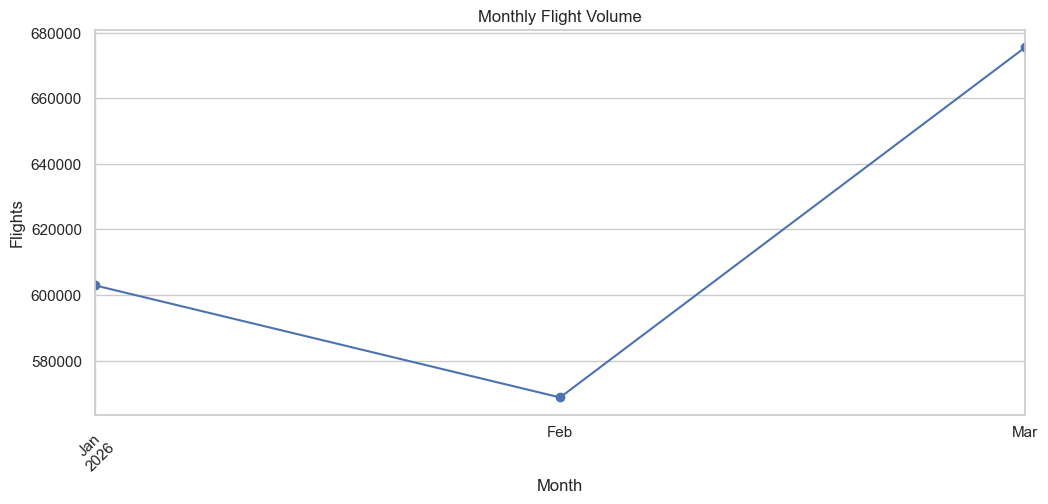

In [22]:
plt.figure(figsize=(12, 5))
monthly_flights.plot(marker="o")
plt.title("Monthly Flight Volume")
plt.xlabel("Month")
plt.ylabel("Flights")
plt.xticks(rotation=45)
plt.show()

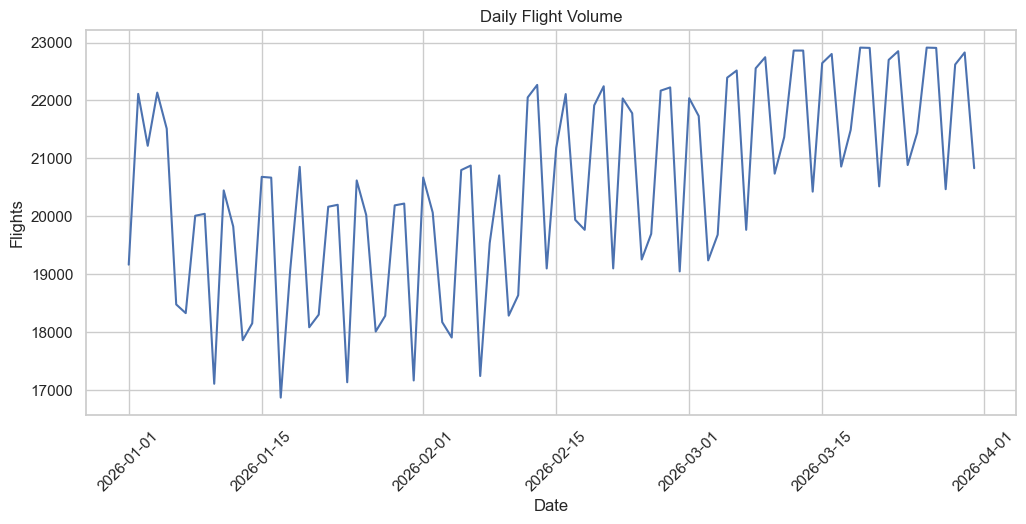

In [23]:
# Daily flight volume helps identify operational peaks and unusual activity.
daily_flights = df.groupby("fl_date").size()

plt.figure(figsize=(12, 5))
plt.plot(daily_flights.index, daily_flights.values)
plt.title("Daily Flight Volume")
plt.xlabel("Date")
plt.ylabel("Flights")
plt.xticks(rotation=45)
plt.show()

## 6.4 Day-of-week and monthly flight patterns

In [24]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_counts = df["day_of_week"].value_counts().reindex(day_order)
day_counts

day_of_week
Monday       279832
Tuesday      250644
Wednesday    233063
Thursday     278223
Friday       282049
Saturday     245173
Sunday       278258
Name: count, dtype: int64

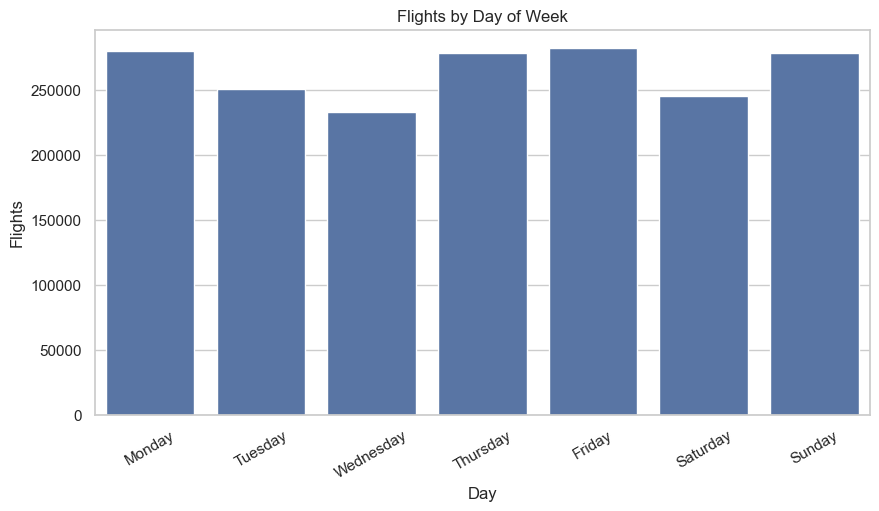

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title("Flights by Day of Week")
plt.xlabel("Day")
plt.ylabel("Flights")
plt.xticks(rotation=30)
plt.show()

In [26]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

month_counts = df["month_name"].value_counts().reindex(month_order)
month_counts

month_name
January      602953.0
February     568789.0
March        675500.0
April             NaN
May               NaN
June              NaN
July              NaN
August            NaN
September         NaN
October           NaN
November          NaN
December          NaN
Name: count, dtype: float64

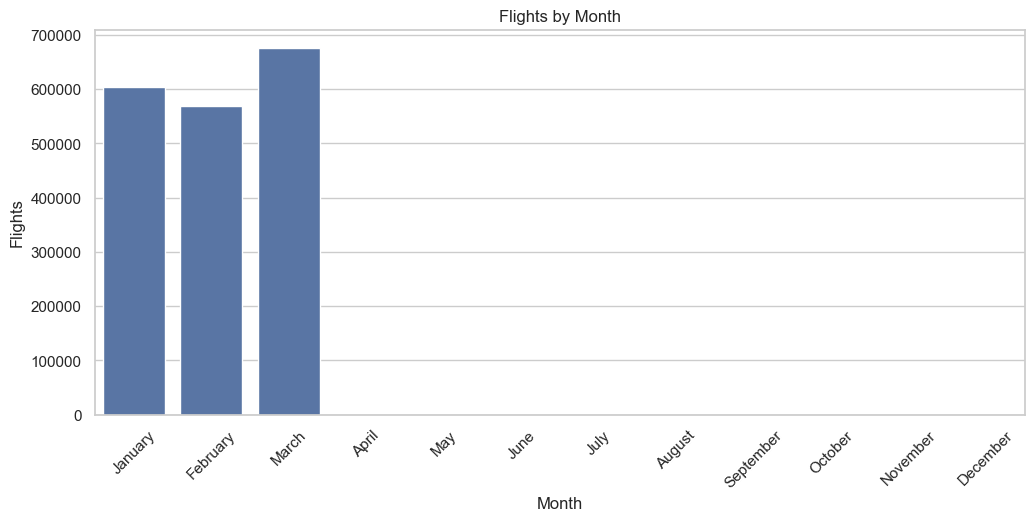

In [27]:
plt.figure(figsize=(12, 5))
sns.barplot(x=month_counts.index, y=month_counts.values)
plt.title("Flights by Month")
plt.xlabel("Month")
plt.ylabel("Flights")
plt.xticks(rotation=45)
plt.show()

## 6.5 Delay distributions

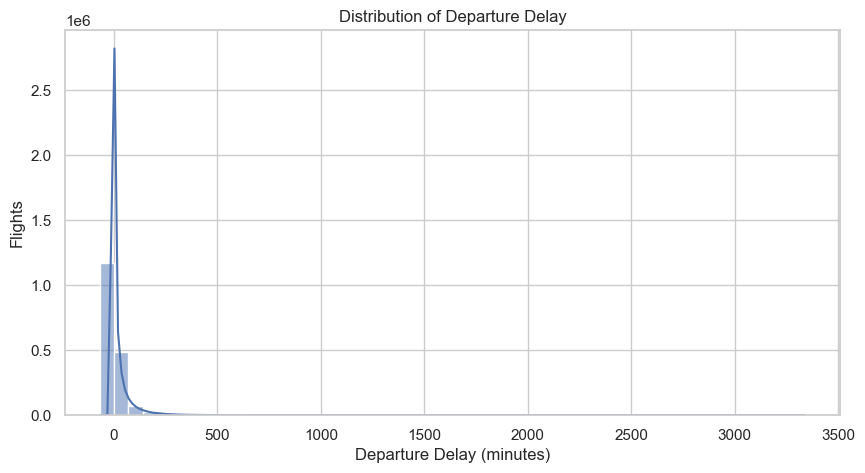

In [28]:
# Distribution of departure delays.
plt.figure(figsize=(10, 5))
sns.histplot(completed_df["dep_delay"].dropna(), bins=50, kde=True)
plt.title("Distribution of Departure Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Flights")
plt.show()

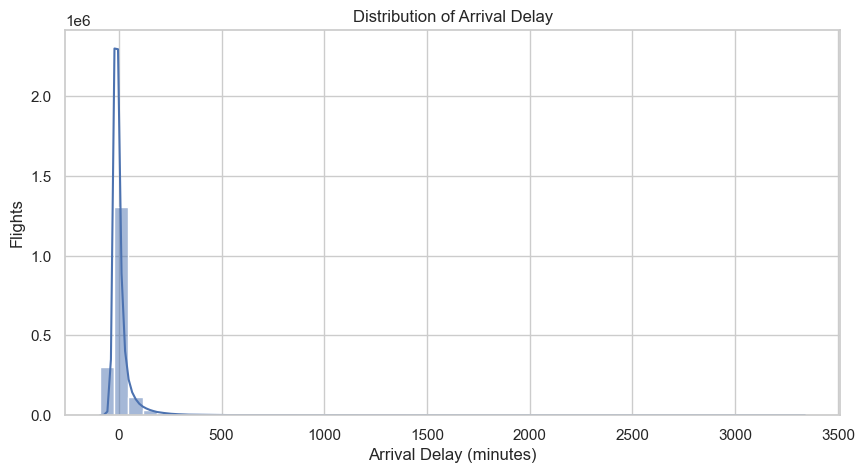

In [29]:
# Distribution of arrival delays.
plt.figure(figsize=(10, 5))
sns.histplot(completed_df["arr_delay"].dropna(), bins=50, kde=True)
plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Flights")
plt.show()

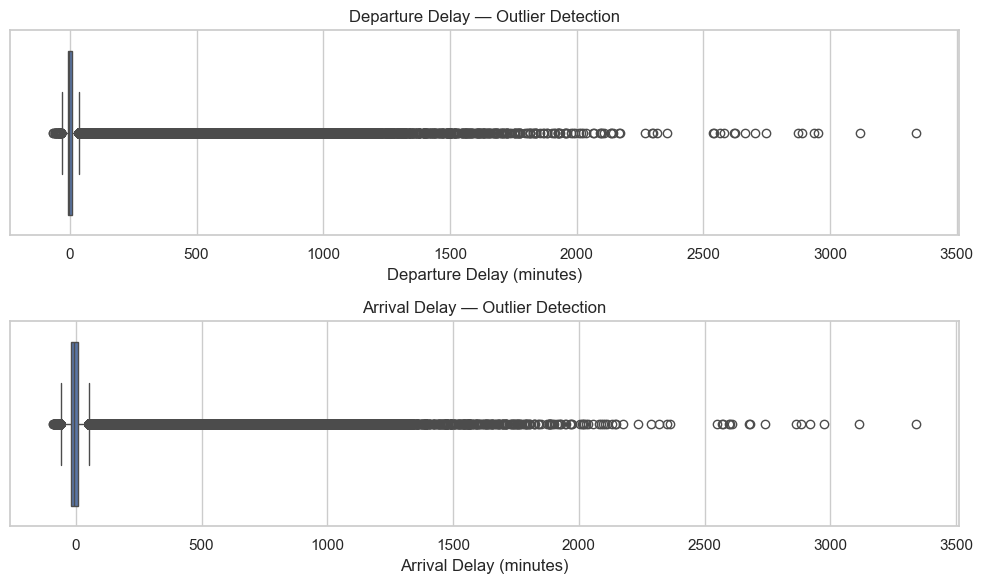

In [30]:
# Boxplots provide a compact view of spread and potential extreme observations.
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

sns.boxplot(x=completed_df["dep_delay"], ax=axes[0])
axes[0].set_title("Departure Delay — Outlier Detection")
axes[0].set_xlabel("Departure Delay (minutes)")

sns.boxplot(x=completed_df["arr_delay"], ax=axes[1])
axes[1].set_title("Arrival Delay — Outlier Detection")
axes[1].set_xlabel("Arrival Delay (minutes)")

plt.tight_layout()
plt.show()

In [31]:
# Descriptive statistics help assess skewness and the difference between mean and median.
print("Arrival delay skewness:", completed_df["arr_delay"].skew())
print("Median arrival delay:", completed_df["arr_delay"].median())
print("Mean arrival delay:", completed_df["arr_delay"].mean())

Arrival delay skewness: 9.721414180841629
Median arrival delay: -7.0
Mean arrival delay: 7.249089144216867


## 6.6 IQR-based outlier analysis

The IQR method is used to flag unusual observations.  
**IQR = Q3 − Q1**. A value is flagged when it falls below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.

Outliers are investigated rather than automatically deleted because extreme delays can represent genuine operational events.

In [32]:
# Departure-delay IQR boundaries.
q1_dep = completed_df["dep_delay"].quantile(0.25)
q3_dep = completed_df["dep_delay"].quantile(0.75)
iqr_dep = q3_dep - q1_dep

lower_dep = q1_dep - 1.5 * iqr_dep
upper_dep = q3_dep + 1.5 * iqr_dep

print("Departure Delay — Q1:", q1_dep)
print("Departure Delay — Q3:", q3_dep)
print("Departure Delay — IQR:", iqr_dep)
print("Lower bound:", lower_dep)
print("Upper bound:", upper_dep)

Departure Delay — Q1: -7.0
Departure Delay — Q3: 10.0
Departure Delay — IQR: 17.0
Lower bound: -32.5
Upper bound: 35.5


In [33]:
# Identify and quantify departure-delay outliers.
dep_outliers = completed_df[
    (completed_df["dep_delay"] < lower_dep) |
    (completed_df["dep_delay"] > upper_dep)
]

print("Departure delay outliers:", len(dep_outliers))
print("Departure outlier %:", round(len(dep_outliers) / len(completed_df) * 100, 2))

Departure delay outliers: 226904
Departure outlier %: 12.75


In [34]:
# Arrival-delay IQR boundaries.
q1_arr = completed_df["arr_delay"].quantile(0.25)
q3_arr = completed_df["arr_delay"].quantile(0.75)
iqr_arr = q3_arr - q1_arr

lower_arr = q1_arr - 1.5 * iqr_arr
upper_arr = q3_arr + 1.5 * iqr_arr

print("Arrival Delay — Q1:", q1_arr)
print("Arrival Delay — Q3:", q3_arr)
print("Arrival Delay — IQR:", iqr_arr)
print("Lower bound:", lower_arr)
print("Upper bound:", upper_arr)

Arrival Delay — Q1: -18.0
Arrival Delay — Q3: 10.0
Arrival Delay — IQR: 28.0
Lower bound: -60.0
Upper bound: 52.0


In [35]:
# Identify and quantify arrival-delay outliers.
arr_outliers = completed_df[
    (completed_df["arr_delay"] < lower_arr) |
    (completed_df["arr_delay"] > upper_arr)
]

print("Arrival delay outliers:", len(arr_outliers))
print("Arrival outlier %:", round(len(arr_outliers) / len(completed_df) * 100, 2))

Arrival delay outliers: 161742
Arrival outlier %: 9.09


In [36]:
# Review the most extreme delay observations rather than deleting them automatically.
top_departure_delays = completed_df.sort_values("dep_delay", ascending=False).head(20)
top_departure_delays[
    ["fl_date", "mkt_carrier", "origin", "dest", "dep_delay", "arr_delay"]
]

,fl_date,mkt_carrier,origin,dest,dep_delay,arr_delay
545981,2026-01-29,AA,SDF,DFW,3339.0,3339.0
943931,2026-02-18,AA,MFE,DFW,3120.0,3113.0
164767,2026-01-09,AA,AUS,PHL,2954.0,2975.0
1069948,2026-02-24,AA,HNL,LAX,2937.0,2919.0
1781179,2026-03-29,AA,BDL,MIA,2888.0,2862.0
1412313,2026-03-12,AA,BNA,CLT,2874.0,2882.0
932419,2026-02-17,DL,SDF,DTW,2748.0,2738.0
124764,2026-01-07,AA,MCI,PHX,2706.0,2680.0
1342971,2026-03-09,AA,OMA,DFW,2663.0,2678.0
1366117,2026-03-10,AA,AUS,PHL,2625.0,2610.0


In [37]:
top_arrival_delays = completed_df.sort_values("arr_delay", ascending=False).head(20)
top_arrival_delays[
    ["fl_date", "mkt_carrier", "origin", "dest", "dep_delay", "arr_delay"]
]

,fl_date,mkt_carrier,origin,dest,dep_delay,arr_delay
545981,2026-01-29,AA,SDF,DFW,3339.0,3339.0
943931,2026-02-18,AA,MFE,DFW,3120.0,3113.0
164767,2026-01-09,AA,AUS,PHL,2954.0,2975.0
1069948,2026-02-24,AA,HNL,LAX,2937.0,2919.0
1412313,2026-03-12,AA,BNA,CLT,2874.0,2882.0
1781179,2026-03-29,AA,BDL,MIA,2888.0,2862.0
932419,2026-02-17,DL,SDF,DTW,2748.0,2738.0
124764,2026-01-07,AA,MCI,PHX,2706.0,2680.0
1342971,2026-03-09,AA,OMA,DFW,2663.0,2678.0
1366117,2026-03-10,AA,AUS,PHL,2625.0,2610.0


# 7. Bivariate Analysis

Bivariate analysis studies the relationship between two variables.  
The focus here is on airline, airport, route, time, cancellation, diversion, and operational relationships.

## 7.1 Airline performance

In [38]:
# Create an airline-level summary using both volume and performance metrics.
airline_summary = df.groupby("mkt_carrier").agg(
    flights=("mkt_carrier", "size"),
    cancellations=("cancelled", "sum"),
    diversions=("diverted", "sum"),
    avg_dep_delay=("dep_delay", "mean"),
    avg_arr_delay=("arr_delay", "mean")
)

airline_summary["cancellation_rate"] = (
    airline_summary["cancellations"] / airline_summary["flights"] * 100
)

airline_summary["diversion_rate"] = (
    airline_summary["diversions"] / airline_summary["flights"] * 100
)

airline_delay = (
    completed_df.groupby("mkt_carrier")["arr_del15"]
    .mean()
    .mul(100)
)

airline_summary["arrival_delay_rate"] = airline_delay

airline_summary.sort_values("flights", ascending=False)

,flights,cancellations,diversions,avg_dep_delay,avg_arr_delay,cancellation_rate,diversion_rate,arrival_delay_rate
mkt_carrier,,,,,,,,
AA,483902,22945.0,1492.0,17.265050,10.322157,4.741663,0.308327,23.042887
DL,386832,14328.0,840.0,12.048937,5.853817,3.703933,0.217149,20.131893
UA,358108,9204.0,998.0,12.809870,6.235863,2.570174,0.278687,19.804200
WN,327083,5659.0,624.0,11.409398,3.200954,1.730142,0.190777,20.071696
AS,116489,2158.0,386.0,8.484621,2.175787,1.852535,0.331362,18.582650
B6,57320,3010.0,153.0,19.984565,15.625995,5.251221,0.266923,31.207415
F9,50557,1405.0,81.0,18.496840,13.014408,2.779041,0.160215,26.753072
NK,36379,3123.0,55.0,24.735279,19.661396,8.584623,0.151186,35.423632
G4,30572,479.0,108.0,16.848428,13.490645,1.566793,0.353264,24.929131


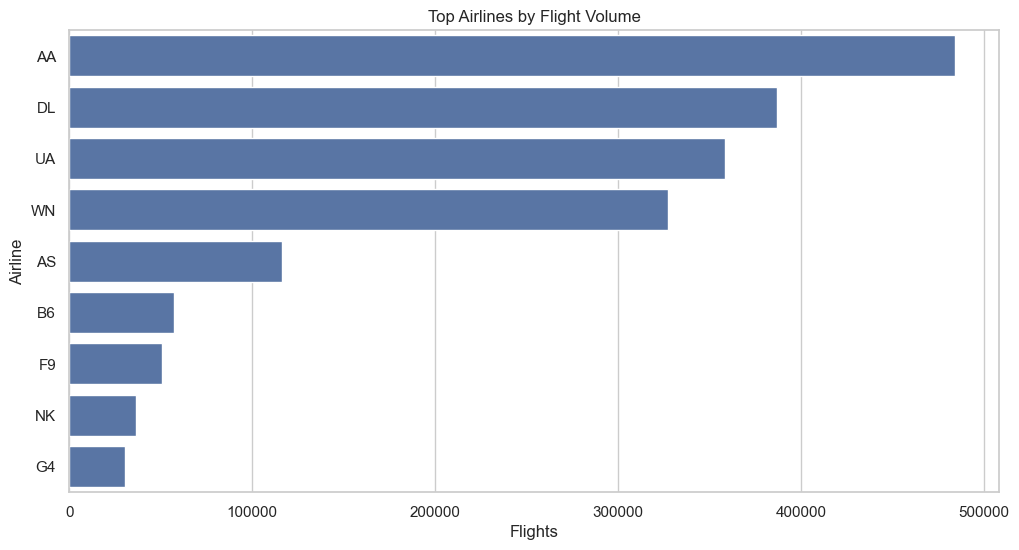

In [39]:
# Airlines with the highest flight volume.
top_airlines = airline_summary.sort_values("flights", ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_airlines["flights"], y=top_airlines.index)
plt.title("Top Airlines by Flight Volume")
plt.xlabel("Flights")
plt.ylabel("Airline")
plt.show()

In [40]:
# Compare cancellation rates across airlines.
airline_cancel = (
    df.groupby("mkt_carrier")["cancelled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

airline_cancel.head(15)

mkt_carrier
NK    8.584623
B6    5.251221
AA    4.741663
DL    3.703933
F9    2.779041
UA    2.570174
AS    1.852535
WN    1.730142
G4    1.566793
Name: cancelled, dtype: float64

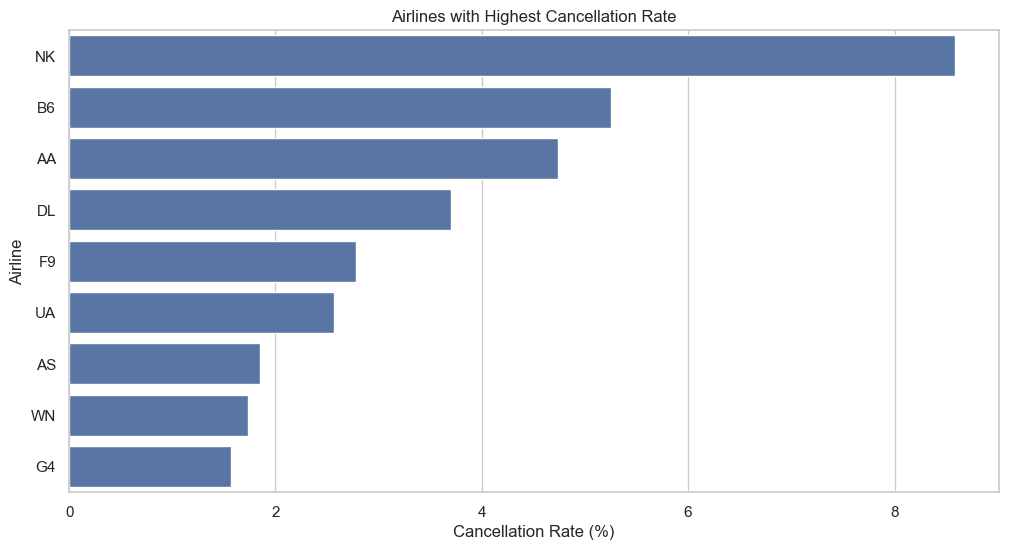

In [41]:
plt.figure(figsize=(12, 6))
sns.barplot(x=airline_cancel.head(15).values, y=airline_cancel.head(15).index)
plt.title("Airlines with Highest Cancellation Rate")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Airline")
plt.show()

In [42]:
# Compare average arrival delay across airlines.
airline_delay = (
    completed_df.groupby("mkt_carrier")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
)

airline_delay.head(15)

mkt_carrier
NK    19.661396
B6    15.625995
G4    13.490645
F9    13.014408
AA    10.322157
UA     6.235863
DL     5.853817
WN     3.200954
AS     2.175787
Name: arr_delay, dtype: float64

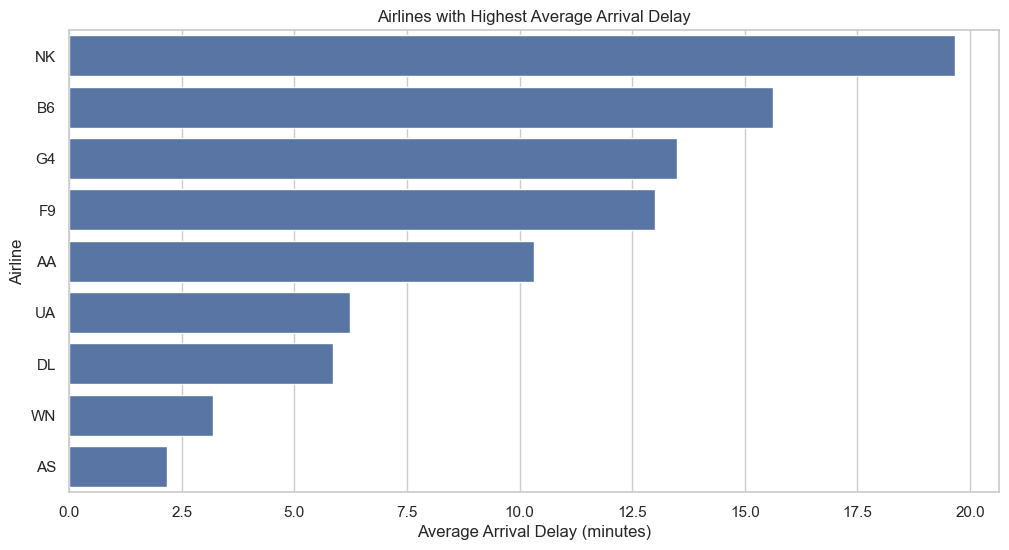

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(x=airline_delay.head(15).values, y=airline_delay.head(15).index)
plt.title("Airlines with Highest Average Arrival Delay")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Airline")
plt.show()

In [44]:
# Delay rate uses the 15-minute operational threshold.
airline_delay_rate = (
    completed_df.groupby("mkt_carrier")["arr_delay"]
    .apply(lambda x: (x >= 15).mean() * 100)
    .sort_values(ascending=False)
)

airline_delay_rate.head(15)

mkt_carrier
NK    35.423632
B6    31.207415
F9    26.753072
G4    24.929131
AA    23.042887
DL    20.131893
WN    20.071696
UA    19.804200
AS    18.582650
Name: arr_delay, dtype: float64

## 7.2 Airport analysis

In [45]:
# Identify the busiest origin airports.
top_origins = df["origin"].value_counts().head(15)
top_origins

origin
ORD    88327
ATL    82965
DEN    74619
DFW    72321
CLT    55461
PHX    51866
LAX    45488
MCO    42632
LAS    42030
IAH    41268
LGA    40594
SEA    39847
DCA    36466
SFO    34732
EWR    33544
Name: count, dtype: int64

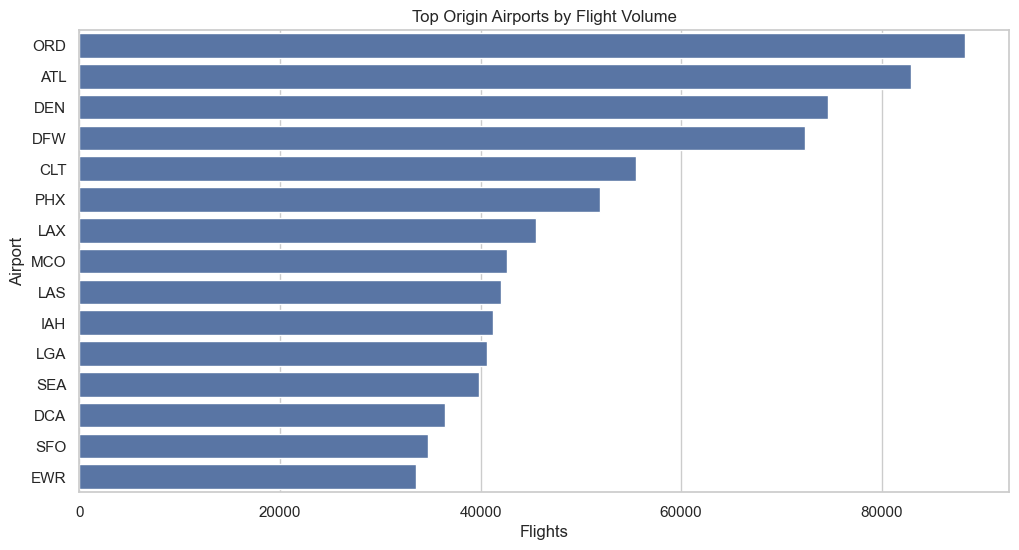

In [46]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_origins.values, y=top_origins.index)
plt.title("Top Origin Airports by Flight Volume")
plt.xlabel("Flights")
plt.ylabel("Airport")
plt.show()

In [47]:
# Identify airports with the highest average departure delay.
airport_delay = (
    completed_df.groupby("origin")["dep_delay"]
    .mean()
    .sort_values(ascending=False)
)

airport_delay.head(15)

origin
PAH    75.352113
ART    71.723529
JST    66.932515
MQT    57.000000
IMT    55.807229
BGM    48.093023
LWB    47.682540
HGR    47.346154
EAU    44.930556
PLN    42.600000
FOD    41.680556
LAF    40.963504
CMX    40.394904
PBG    40.120968
CIU    39.059603
Name: dep_delay, dtype: float64

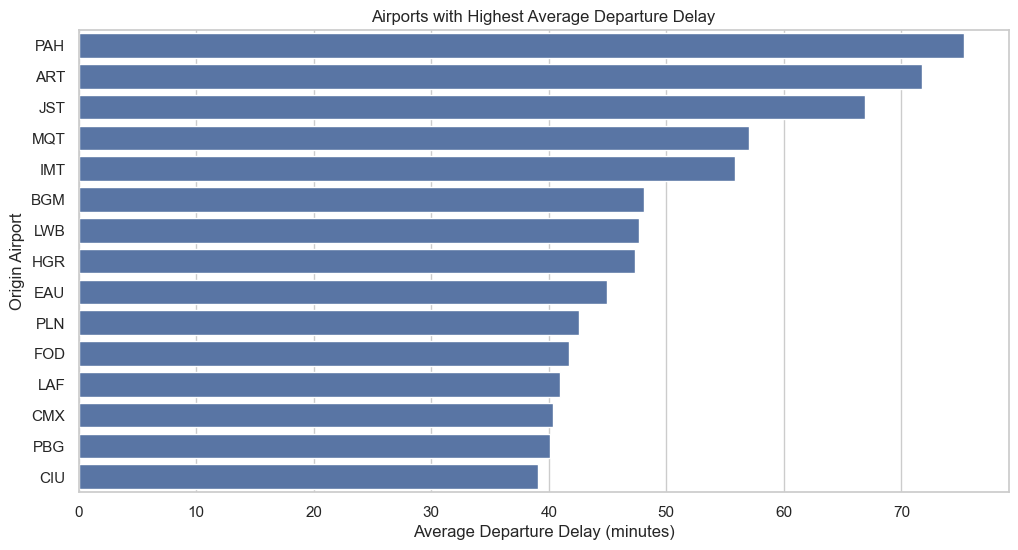

In [48]:
plt.figure(figsize=(12, 6))
sns.barplot(x=airport_delay.head(15).values, y=airport_delay.head(15).index)
plt.title("Airports with Highest Average Departure Delay")
plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Origin Airport")
plt.show()

In [49]:
# Identify destination airports with the highest average arrival delay.
arrival_airport_delay = (
    completed_df.groupby("dest")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
)

arrival_airport_delay.head(15)

dest
PAH    72.013889
JST    71.737500
LWB    65.384615
SHD    59.250000
VCT    51.272727
BGM    51.116279
CMX    47.512658
MQT    46.076642
IMT    42.824242
CIU    38.520000
MGW    37.928571
LAF    36.948148
ESC    35.000000
ITH    34.767507
AZO    34.281250
Name: arr_delay, dtype: float64

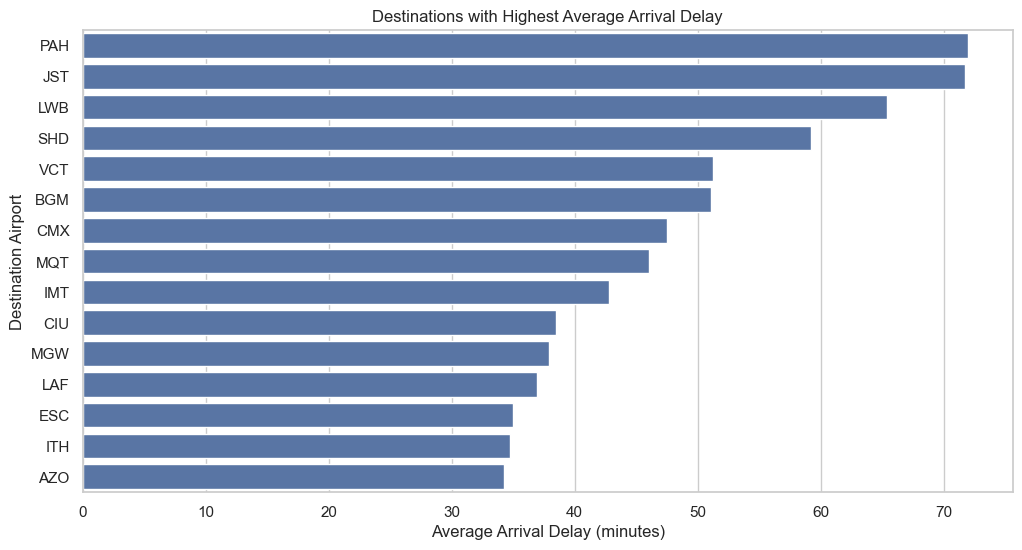

In [50]:
plt.figure(figsize=(12, 6))
sns.barplot(x=arrival_airport_delay.head(15).values, y=arrival_airport_delay.head(15).index)
plt.title("Destinations with Highest Average Arrival Delay")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Destination Airport")
plt.show()

## 7.3 Route analysis

In [51]:
# Create a reusable route identifier.
df["route"] = df["origin"].astype(str) + " → " + df["dest"].astype(str)
completed_df["route"] = (
    completed_df["origin"].astype(str) + " → " + completed_df["dest"].astype(str)
)

In [52]:
# Busiest routes by completed-flight volume.
top_routes = completed_df["route"].value_counts().head(15)
top_routes

route
SFO → LAX    2715
LAX → SFO    2714
ORD → LGA    2576
LGA → ORD    2557
HNL → OGG    2484
OGG → HNL    2482
DEN → PHX    2360
PHX → DEN    2360
JFK → LAX    2285
LAX → JFK    2282
DCA → BOS    2139
LAX → LAS    2139
LAS → LAX    2137
BOS → DCA    2126
MCO → ATL    2085
Name: count, dtype: int64

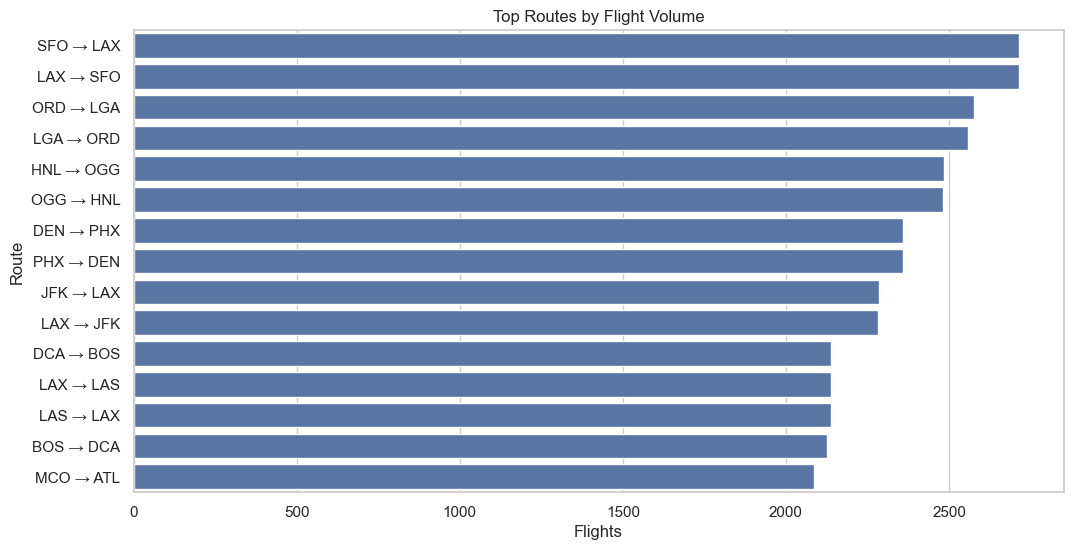

In [53]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_routes.values, y=top_routes.index)
plt.title("Top Routes by Flight Volume")
plt.xlabel("Flights")
plt.ylabel("Route")
plt.show()

In [54]:
# Routes with the highest average arrival delay.
route_delay = (
    completed_df.groupby("route")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
)

route_delay.head(15)

route
PHL → ACY    810.000000
PHL → ISP    311.000000
MDT → FLL    239.785714
FLL → MDT    227.071429
LAX → BUF    216.600000
ORD → STX    156.461538
TTN → FLL    155.000000
LIT → SFB    154.000000
STX → ORD    150.307692
CHA → FLL    144.285714
IND → SAV    140.625000
TYS → AUS    137.500000
LYH → IAD    135.625000
AUS → TYS    131.000000
SYR → BNA    127.750000
Name: arr_delay, dtype: float64

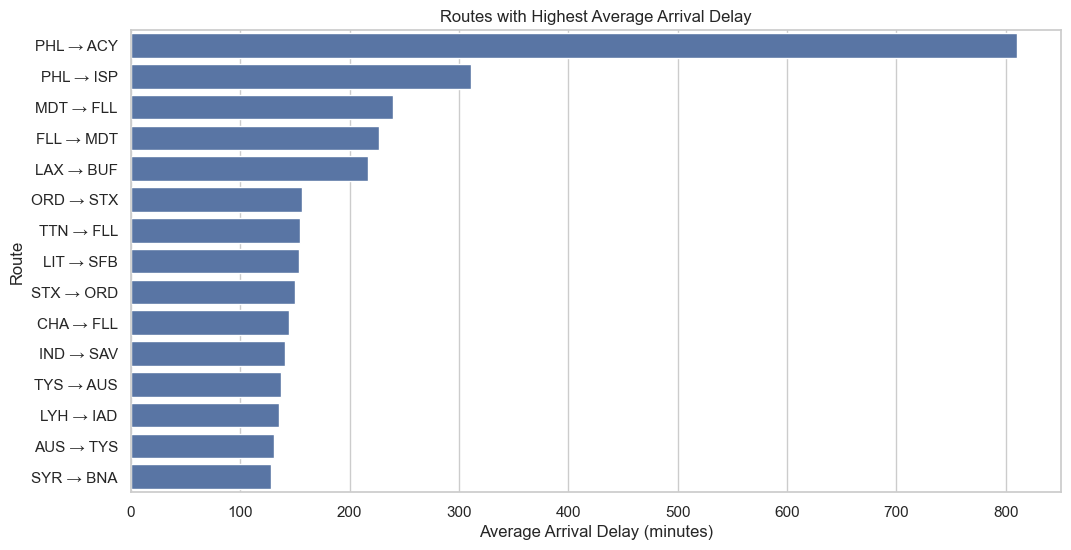

In [55]:
plt.figure(figsize=(12, 6))
sns.barplot(x=route_delay.head(15).values, y=route_delay.head(15).index)
plt.title("Routes with Highest Average Arrival Delay")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Route")
plt.show()

## 7.4 Delay causes

In [56]:
# Delay-cause fields are evaluated together to understand the operational drivers
# of delay minutes.
delay_columns = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

delay_totals = completed_df[delay_columns].sum().sort_values(ascending=False)
delay_totals

late_aircraft_delay    11252035.0
carrier_delay          10291572.0
nas_delay               5573882.0
weather_delay           2044093.0
security_delay            50116.0
dtype: float64

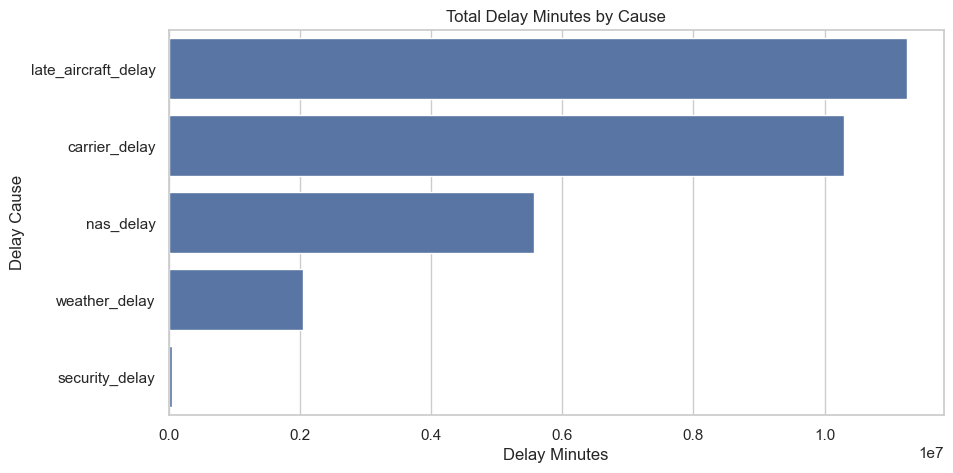

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(x=delay_totals.values, y=delay_totals.index)
plt.title("Total Delay Minutes by Cause")
plt.xlabel("Delay Minutes")
plt.ylabel("Delay Cause")
plt.show()

In [58]:
# Convert total delay minutes into percentage contribution.
delay_percentage = (delay_totals / delay_totals.sum() * 100).round(2)
delay_percentage

late_aircraft_delay    38.52
carrier_delay          35.23
nas_delay              19.08
weather_delay           7.00
security_delay          0.17
dtype: float64

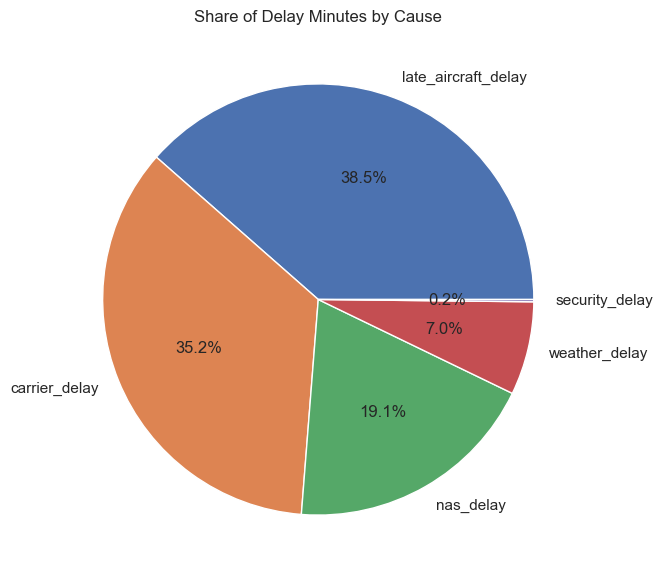

In [59]:
delay_percentage.plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7))
plt.title("Share of Delay Minutes by Cause")
plt.ylabel("")
plt.show()

In [60]:
# Compare delay causes across airlines.
airline_delay_causes = completed_df.groupby("mkt_carrier")[delay_columns].sum()
airline_delay_causes.head()

,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
mkt_carrier,,,,,
AA,3103436.0,837606.0,1281853.0,18212.0,3917227.0
AS,411193.0,84526.0,213728.0,3379.0,475514.0
B6,344901.0,37005.0,283291.0,3454.0,588586.0
DL,2808001.0,545189.0,1051938.0,4258.0,1415570.0
F9,315950.0,32132.0,219857.0,0.0,541871.0


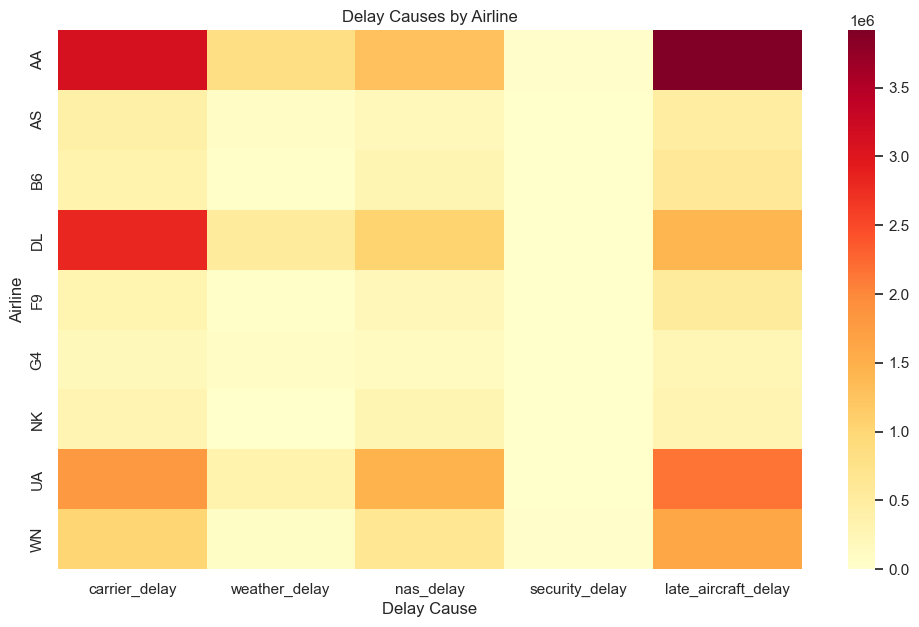

In [61]:
plt.figure(figsize=(12, 7))
sns.heatmap(airline_delay_causes, cmap="YlOrRd")
plt.title("Delay Causes by Airline")
plt.xlabel("Delay Cause")
plt.ylabel("Airline")
plt.show()

## 7.5 Cancellation analysis

In [62]:
# Focus specifically on cancelled flights.
cancelled_df = df[df["cancelled"] == 1].copy()

print("Cancelled flights:", len(cancelled_df))
print("Cancellation rate:", round(df["cancelled"].mean() * 100, 2), "%")

Cancelled flights: 62311
Cancellation rate: 3.37 %


In [63]:
# Review cancellation codes, including missing codes.
df["cancellation_code"].value_counts(dropna=False)

cancellation_code
NaN    1784931
B        47348
A        10042
C         4852
D           69
Name: count, dtype: int64

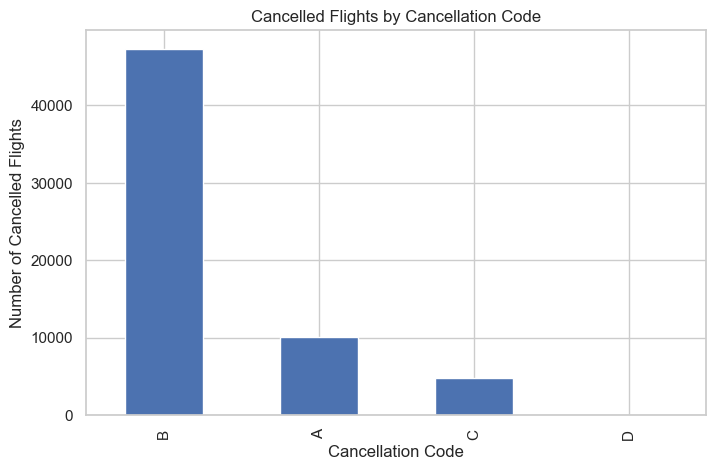

In [64]:
cancellation_reasons = (
    df.loc[df["cancelled"] == 1, "cancellation_code"]
    .value_counts()
)

plt.figure(figsize=(8, 5))
cancellation_reasons.plot(kind="bar")
plt.title("Cancelled Flights by Cancellation Code")
plt.xlabel("Cancellation Code")
plt.ylabel("Number of Cancelled Flights")
plt.show()

In [65]:
# Airlines with the largest absolute number of cancellations.
cancel_by_airline = cancelled_df["mkt_carrier"].value_counts().head(15)
cancel_by_airline

mkt_carrier
AA    22945
DL    14328
UA     9204
WN     5659
NK     3123
B6     3010
AS     2158
F9     1405
G4      479
Name: count, dtype: int64

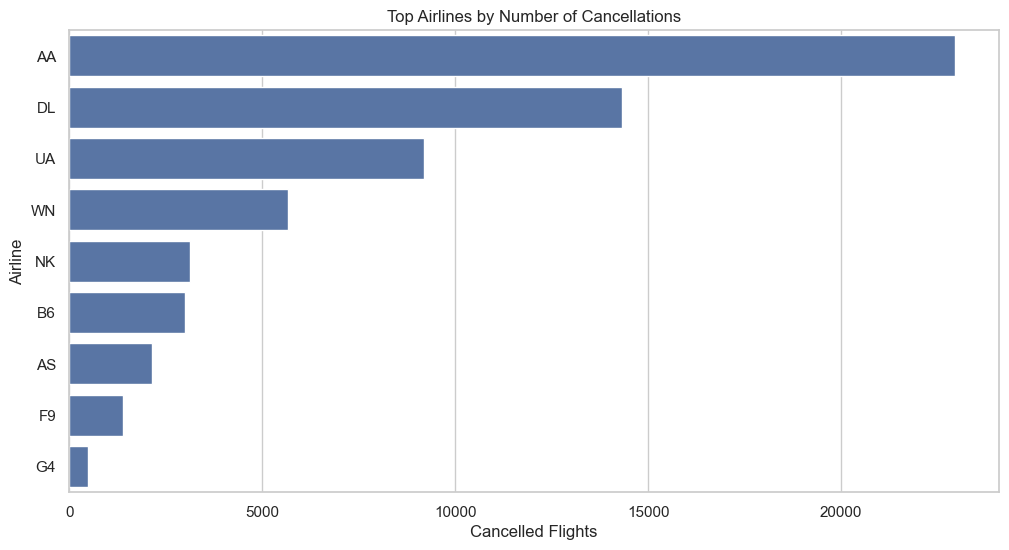

In [66]:
plt.figure(figsize=(12, 6))
sns.barplot(x=cancel_by_airline.values, y=cancel_by_airline.index)
plt.title("Top Airlines by Number of Cancellations")
plt.xlabel("Cancelled Flights")
plt.ylabel("Airline")
plt.show()

In [67]:
# Origin airports with the largest number of cancellations.
cancel_by_origin = cancelled_df["origin"].value_counts().head(15)
cancel_by_origin

origin
LGA    3611
DFW    3330
ORD    3269
CLT    3010
ATL    2736
DCA    2275
BOS    1952
JFK    1861
EWR    1835
MCO    1495
PHL    1453
FLL    1199
DTW    1056
DEN    1023
MIA     995
Name: count, dtype: int64

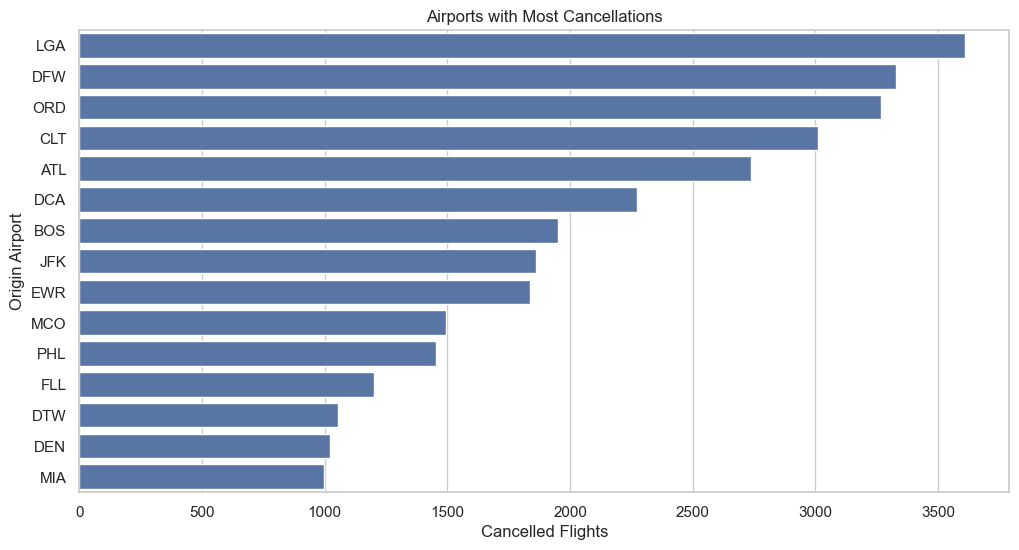

In [68]:
plt.figure(figsize=(12, 6))
sns.barplot(x=cancel_by_origin.values, y=cancel_by_origin.index)
plt.title("Airports with Most Cancellations")
plt.xlabel("Cancelled Flights")
plt.ylabel("Origin Airport")
plt.show()

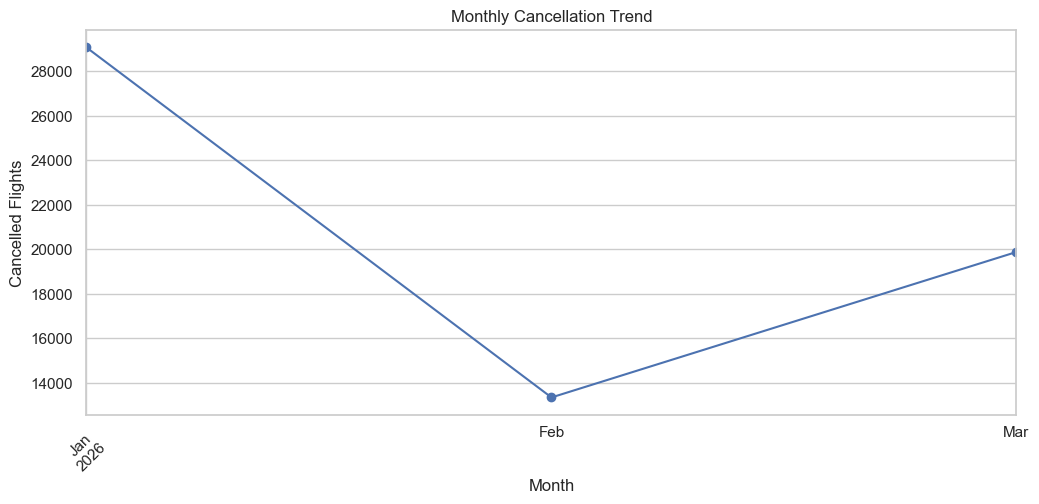

In [69]:
# Cancellation trend by month.
monthly_cancelled = cancelled_df.groupby(
    cancelled_df["fl_date"].dt.to_period("M")
).size()

monthly_cancelled.plot(figsize=(12, 5), marker="o")
plt.title("Monthly Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancelled Flights")
plt.xticks(rotation=45)
plt.show()

## 7.6 Diversion analysis

In [70]:
# Focus specifically on diverted flights.
diverted_df = df[df["diverted"] == 1].copy()
print("Diverted flights:", len(diverted_df))

Diverted flights: 4737


In [71]:
diverted_by_airline = diverted_df["mkt_carrier"].value_counts().head(15)
diverted_by_airline

mkt_carrier
AA    1492
UA     998
DL     840
WN     624
AS     386
B6     153
G4     108
F9      81
NK      55
Name: count, dtype: int64

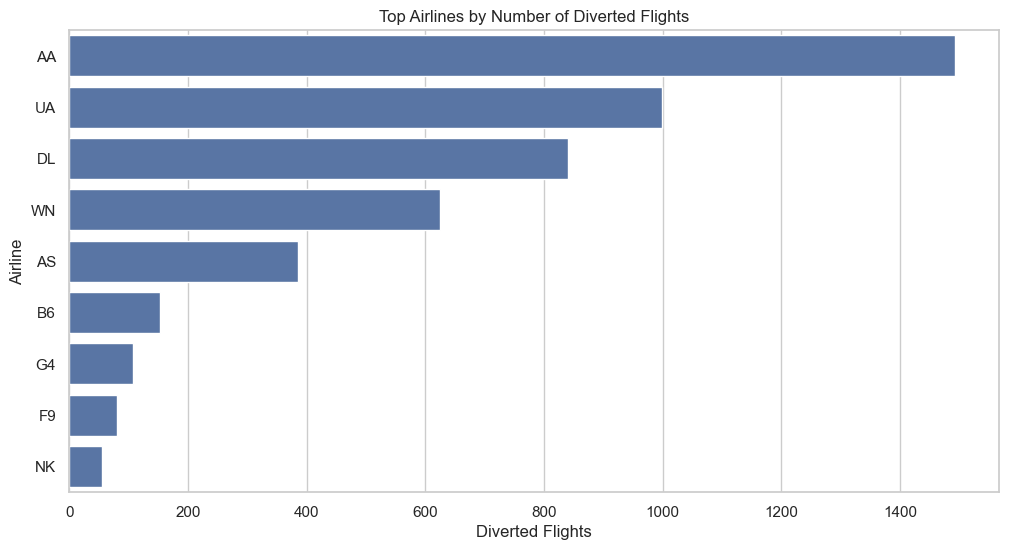

In [72]:
plt.figure(figsize=(12, 6))
sns.barplot(x=diverted_by_airline.values, y=diverted_by_airline.index)
plt.title("Top Airlines by Number of Diverted Flights")
plt.xlabel("Diverted Flights")
plt.ylabel("Airline")
plt.show()

## 7.7 Time-based delay patterns

In [73]:
# Monthly average arrival delay.
monthly_avg_arr_delay = (
    completed_df.groupby(completed_df["fl_date"].dt.to_period("M"))["arr_delay"]
    .mean()
)
monthly_avg_arr_delay

fl_date
2026-01     6.464044
2026-02     3.990915
2026-03    10.701591
Freq: M, Name: arr_delay, dtype: float64

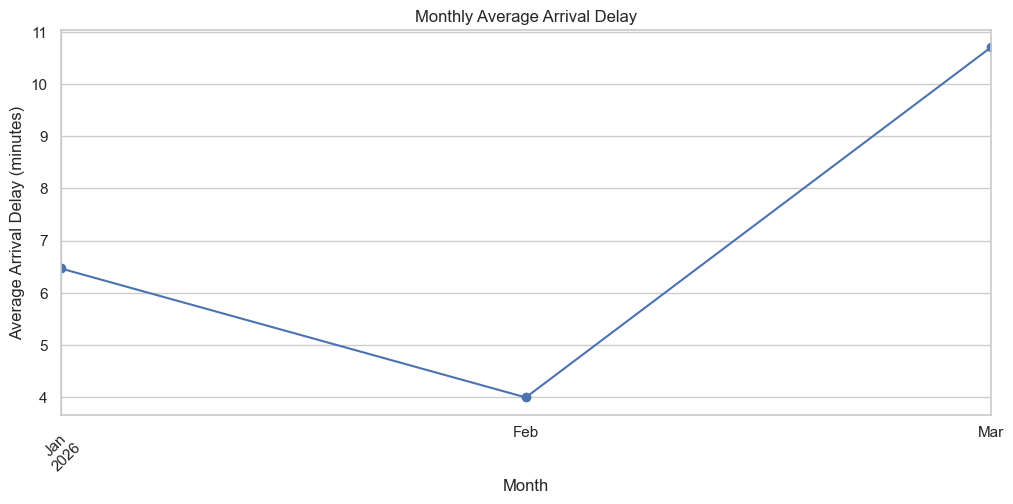

In [74]:
monthly_avg_arr_delay.plot(figsize=(12, 5), marker="o")
plt.title("Monthly Average Arrival Delay")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

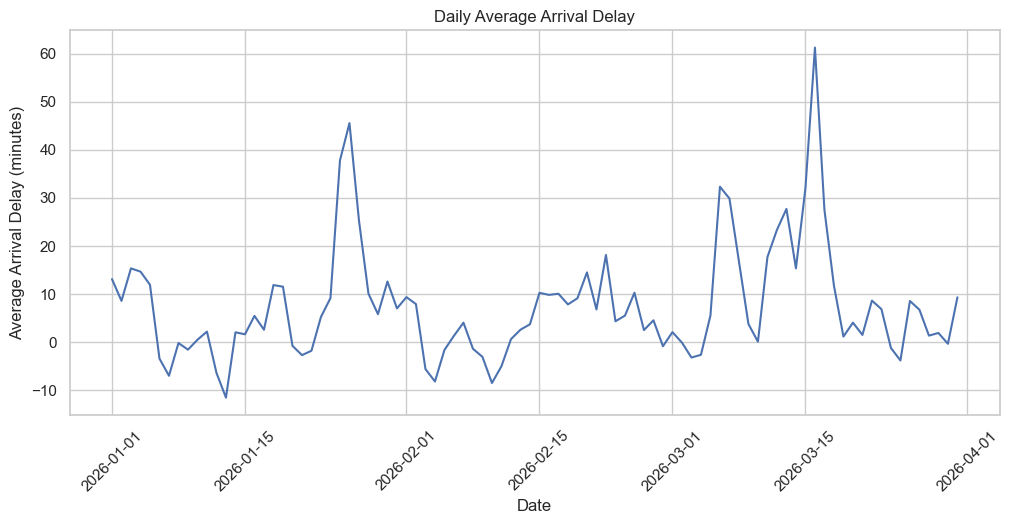

In [75]:
# Daily average arrival delay.
daily_delay = completed_df.groupby("fl_date")["arr_delay"].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_delay.index, daily_delay.values)
plt.title("Daily Average Arrival Delay")
plt.xlabel("Date")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

In [76]:
# Arrival delay rate by day of week.
day_delay_rate = (
    completed_df.groupby("day_of_week")["arr_del15"]
    .mean()
    .mul(100)
    .reindex(day_order)
)
day_delay_rate

day_of_week
Monday       23.126150
Tuesday      17.641859
Wednesday    17.929767
Thursday     20.744745
Friday       23.110227
Saturday     22.491925
Sunday       25.488000
Name: arr_del15, dtype: float64

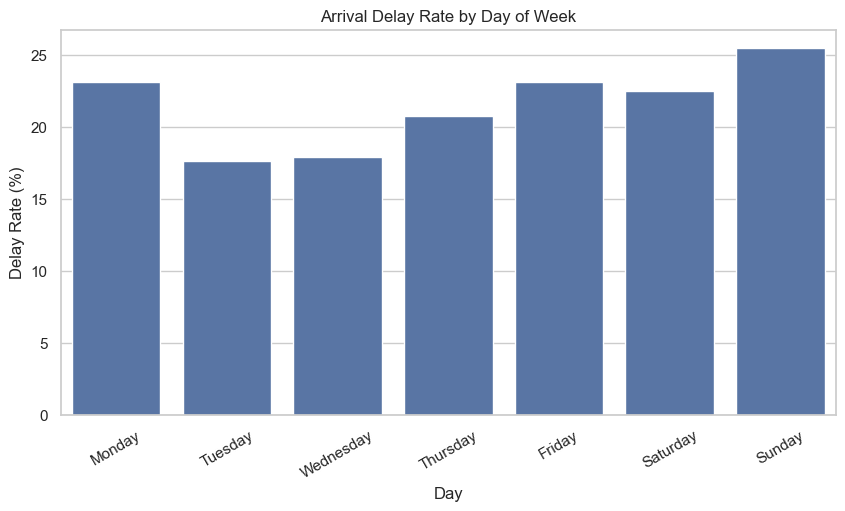

In [77]:
plt.figure(figsize=(10, 5))
sns.barplot(x=day_delay_rate.index, y=day_delay_rate.values)
plt.title("Arrival Delay Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [78]:
# Arrival delay rate by scheduled departure hour.
hour_delay = (
    completed_df.groupby("departure_hour")["arr_del15"]
    .mean()
    .mul(100)
)

hour_delay.head(24)

departure_hour
0     14.095500
1     21.428571
2     24.468085
3     21.621622
4     15.555556
5      9.916477
6     11.952769
7     14.120593
8     16.193075
9     17.309121
10    18.820133
11    20.074080
12    21.646669
13    22.561503
14    23.925848
15    25.373019
16    26.581617
17    27.190260
18    28.196652
19    28.618073
20    28.716491
21    27.064807
22    25.964863
23    18.572825
Name: arr_del15, dtype: float64

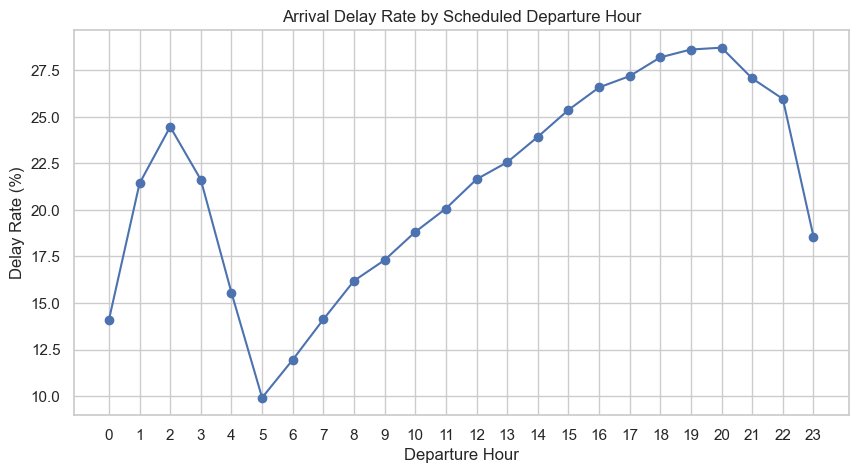

In [79]:
plt.figure(figsize=(10, 5))
hour_delay.plot(kind="line", marker="o")
plt.title("Arrival Delay Rate by Scheduled Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(0, 24))
plt.show()

In [80]:
# Monthly cancellation rate.
monthly_cancellation_rate = (
    df.groupby(df["fl_date"].dt.to_period("M"))["cancelled"]
    .mean()
    .mul(100)
)

monthly_cancellation_rate

fl_date
2026-01    4.822598
2026-02    2.346740
2026-03    2.943745
Freq: M, Name: cancelled, dtype: float64

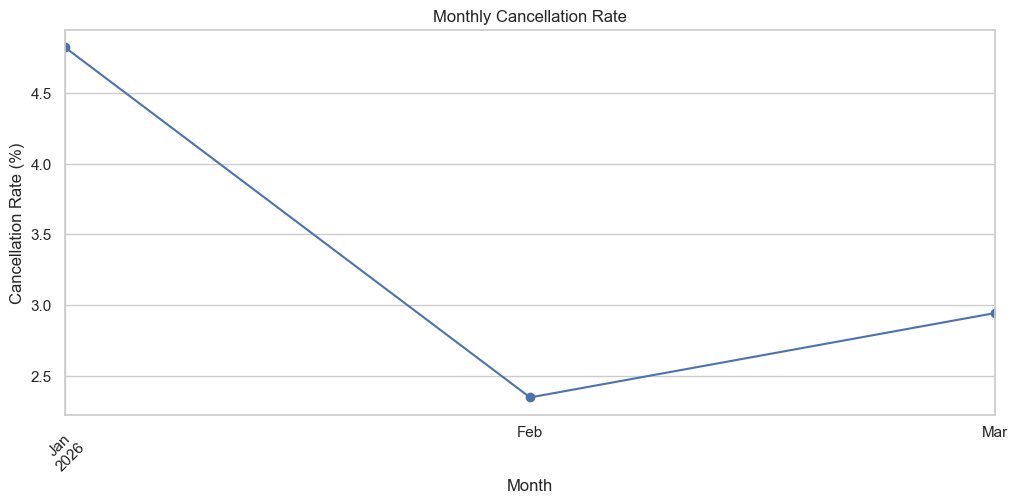

In [81]:
monthly_cancellation_rate.plot(figsize=(12, 5), marker="o")
plt.title("Monthly Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

# 8. Multivariate Analysis

Multivariate analysis examines three or more variables simultaneously.  
This section focuses on operational relationships, correlations, KPI combinations, and weather interactions.

## 8.1 Departure delay vs arrival delay

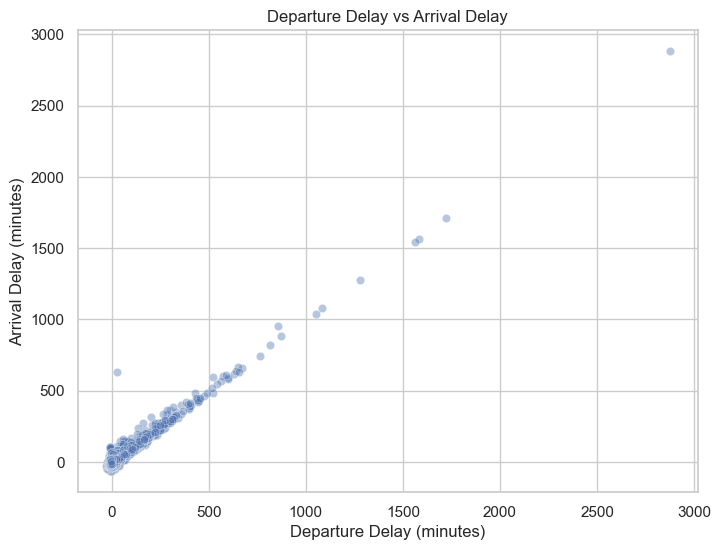

In [82]:
# Sample large datasets for plotting while keeping the full dataset for calculations.
sample_df = completed_df.sample(
    min(10000, len(completed_df)),
    random_state=42
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_df,
    x="dep_delay",
    y="arr_delay",
    alpha=0.4
)
plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

In [83]:
# Pearson correlation quantifies the linear association between the two delays.
delay_correlation = completed_df[["dep_delay", "arr_delay"]].corr().loc[
    "dep_delay", "arr_delay"
]

print(
    "Correlation between departure and arrival delay:",
    round(delay_correlation, 3)
)

Correlation between departure and arrival delay: 0.969


## 8.2 Scheduled vs actual flight duration

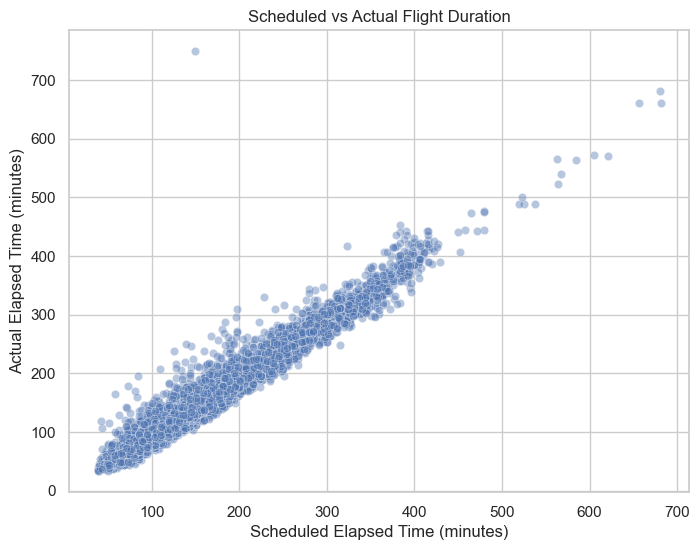

In [84]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_df,
    x="crs_elapsed_time",
    y="actual_elapsed_time",
    alpha=0.4
)
plt.title("Scheduled vs Actual Flight Duration")
plt.xlabel("Scheduled Elapsed Time (minutes)")
plt.ylabel("Actual Elapsed Time (minutes)")
plt.show()

## 8.3 Distance vs air time

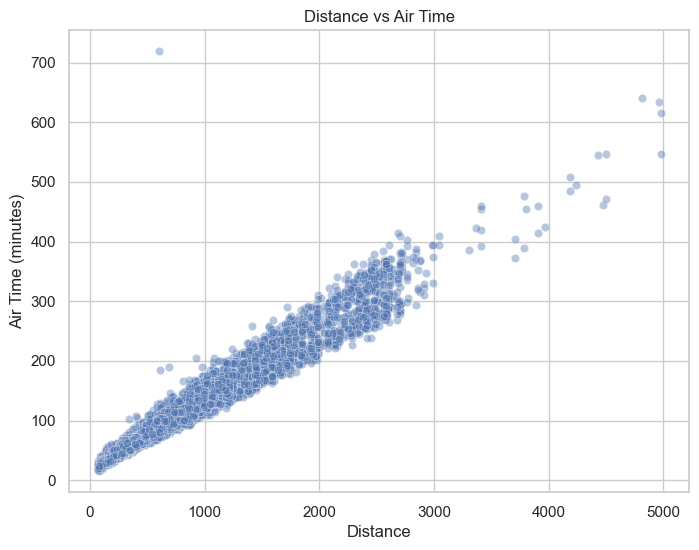

In [85]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_df,
    x="distance",
    y="air_time",
    alpha=0.4
)
plt.title("Distance vs Air Time")
plt.xlabel("Distance")
plt.ylabel("Air Time (minutes)")
plt.show()

## 8.4 Operational correlation heatmap

In [86]:
# Select continuous operational variables for correlation analysis.
correlation_columns = [
    "dep_delay", "arr_delay", "air_time", "distance",
    "taxi_out", "taxi_in", "actual_elapsed_time", "crs_elapsed_time"
]

correlation = completed_df[correlation_columns].corr()
correlation

,dep_delay,arr_delay,air_time,distance,taxi_out,taxi_in,actual_elapsed_time,crs_elapsed_time
dep_delay,1.000000,0.969316,0.005999,0.005164,0.070552,0.023088,0.019180,0.008458
arr_delay,0.969316,1.000000,0.000570,-0.015471,0.215296,0.111634,0.045575,-0.017762
air_time,0.005999,0.000570,1.000000,0.978828,0.002018,0.046851,0.982007,0.987132
distance,0.005164,-0.015471,0.978828,1.000000,-0.013570,0.037559,0.957947,0.976423
taxi_out,0.070552,0.215296,0.002018,-0.013570,1.000000,0.022657,0.157792,0.028320
taxi_in,0.023088,0.111634,0.046851,0.037559,0.022657,1.000000,0.155841,0.077433
actual_elapsed_time,0.019180,0.045575,0.982007,0.957947,0.157792,0.155841,1.000000,0.976735
crs_elapsed_time,0.008458,-0.017762,0.987132,0.976423,0.028320,0.077433,0.976735,1.000000


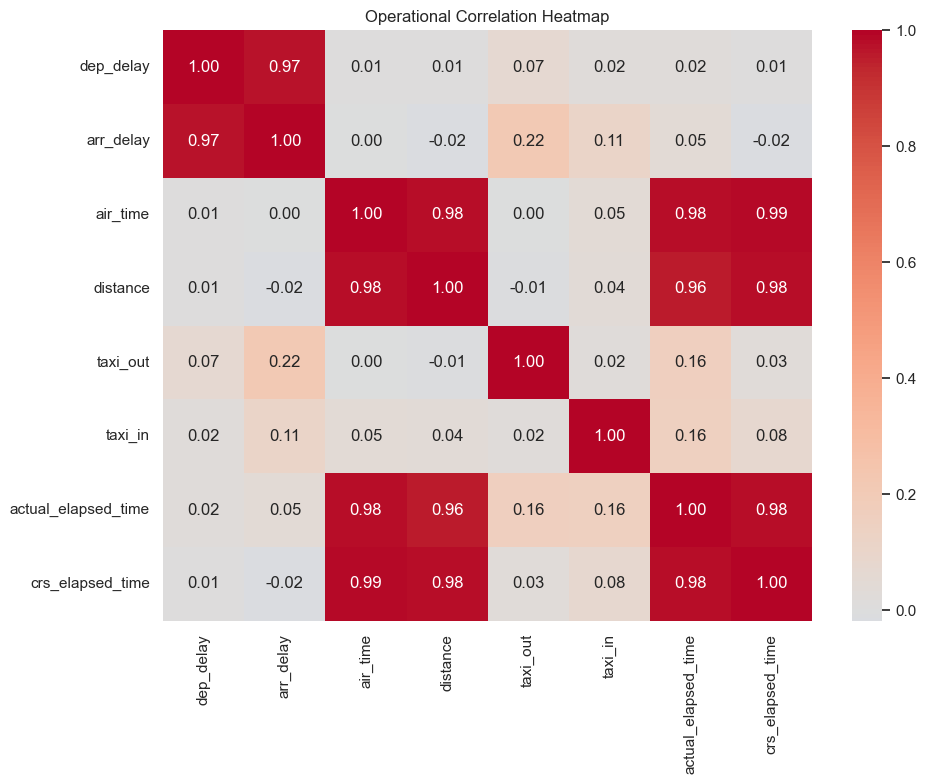

In [87]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Operational Correlation Heatmap")
plt.tight_layout()
plt.show()

## 8.5 Taxi-time analysis

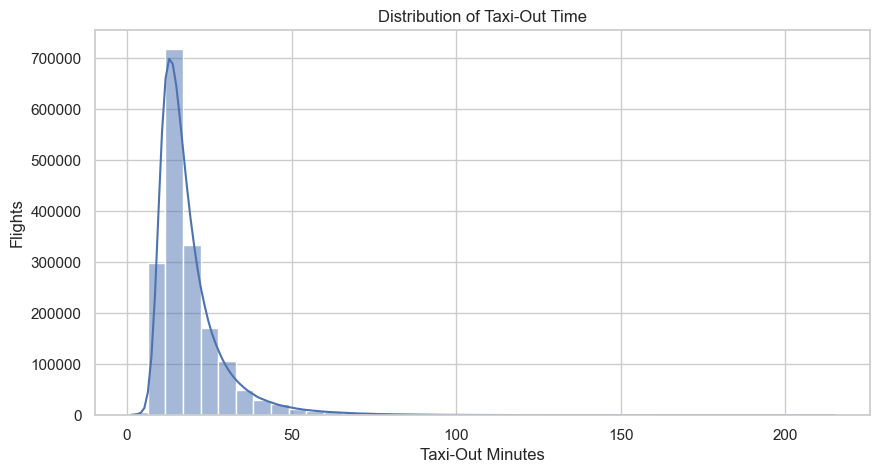

In [88]:
# Taxi-out distribution.
plt.figure(figsize=(10, 5))
sns.histplot(completed_df["taxi_out"].dropna(), bins=40, kde=True)
plt.title("Distribution of Taxi-Out Time")
plt.xlabel("Taxi-Out Minutes")
plt.ylabel("Flights")
plt.show()

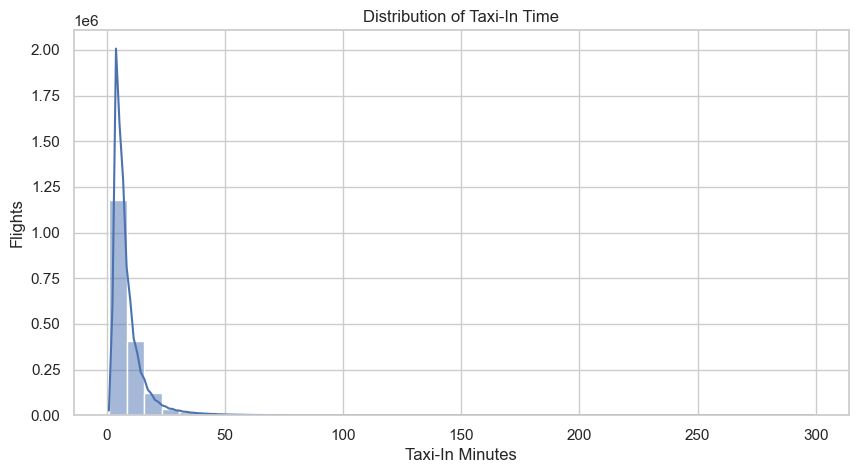

In [89]:
# Taxi-in distribution.
plt.figure(figsize=(10, 5))
sns.histplot(completed_df["taxi_in"].dropna(), bins=40, kde=True)
plt.title("Distribution of Taxi-In Time")
plt.xlabel("Taxi-In Minutes")
plt.ylabel("Flights")
plt.show()

# 9. Weather Impact Analysis

Weather is evaluated as an operational driver rather than simply a descriptive field.

The analysis compares:
- Weather-category frequency
- Departure and arrival delays
- Normal vs bad weather
- Cancellation rate
- Diversion rate
- Airport-level weather impact
- Weather variables and arrival delay relationships
- A consolidated weather impact heatmap

In [90]:
# Review the availability and basic distribution of weather fields.
weather_columns = [
    "weather_category",
    "bad_weather",
    "temperature",
    "precipitation",
    "wind_speed",
    "weather_code"
]

print("Missing weather values:")
print(df[weather_columns].isna().sum())

print("\nWeather categories:")
print(df["weather_category"].value_counts(dropna=False))

Missing weather values:
weather_category    0
bad_weather         0
temperature         0
precipitation       0
wind_speed          0
weather_code        0
dtype: int64

Weather categories:
weather_category
Cloudy    997585
Clear     627886
Rain      165645
Snow       56126
Name: count, dtype: int64


In [91]:
# Number of flights observed under each weather category.
weather_counts = df["weather_category"].value_counts()
weather_counts

weather_category
Cloudy    997585
Clear     627886
Rain      165645
Snow       56126
Name: count, dtype: int64

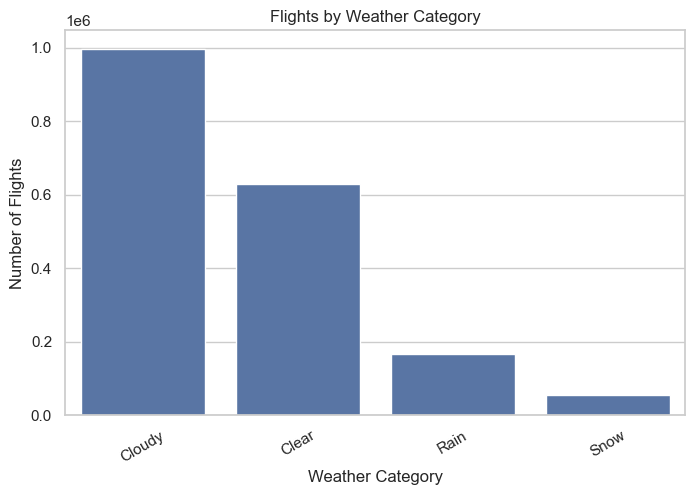

In [92]:
plt.figure(figsize=(8, 5))
sns.barplot(x=weather_counts.index, y=weather_counts.values)
plt.title("Flights by Weather Category")
plt.xlabel("Weather Category")
plt.ylabel("Number of Flights")
plt.xticks(rotation=30)
plt.show()

## 9.1 Weather vs departure delay

In [93]:
weather_dep_delay = (
    completed_df.groupby("weather_category")["dep_delay"]
    .mean()
    .sort_values(ascending=False)
)

weather_dep_delay

weather_category
Snow      33.406061
Rain      22.288794
Cloudy    13.167470
Clear     11.300555
Name: dep_delay, dtype: float64

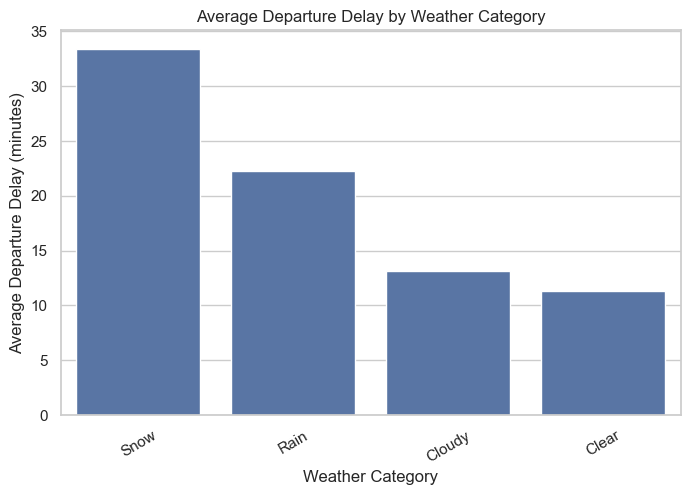

In [94]:
plt.figure(figsize=(8, 5))
sns.barplot(x=weather_dep_delay.index, y=weather_dep_delay.values)
plt.title("Average Departure Delay by Weather Category")
plt.xlabel("Weather Category")
plt.ylabel("Average Departure Delay (minutes)")
plt.xticks(rotation=30)
plt.show()

## 9.2 Weather vs arrival delay

In [95]:
weather_arr_delay = (
    completed_df.groupby("weather_category")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
)

weather_arr_delay

weather_category
Snow      38.208831
Rain      16.865066
Cloudy     6.162450
Clear      4.325837
Name: arr_delay, dtype: float64

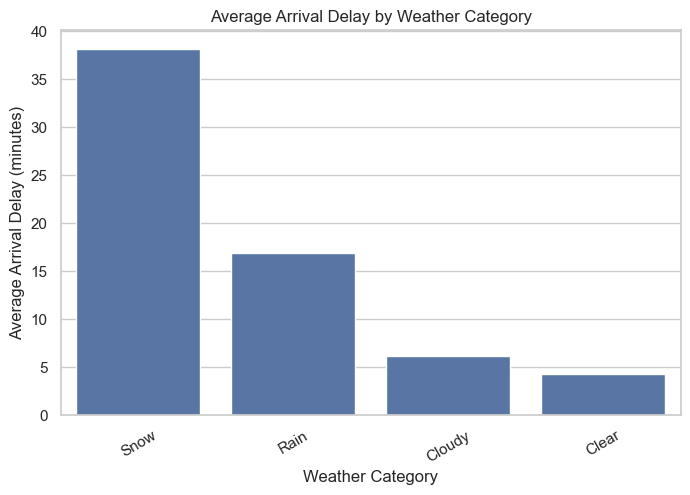

In [96]:
plt.figure(figsize=(8, 5))
sns.barplot(x=weather_arr_delay.index, y=weather_arr_delay.values)
plt.title("Average Arrival Delay by Weather Category")
plt.xlabel("Weather Category")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=30)
plt.show()

## 9.3 Normal weather vs bad weather

In [97]:
bad_weather_delay = (
    completed_df.groupby("bad_weather")["arr_del15"]
    .mean()
    .mul(100)
)

bad_weather_delay.index = [
    "Normal Weather" if x == 0 else "Bad Weather"
    for x in bad_weather_delay.index
]

bad_weather_delay

Normal Weather    20.144593
Bad Weather       33.166024
Name: arr_del15, dtype: float64

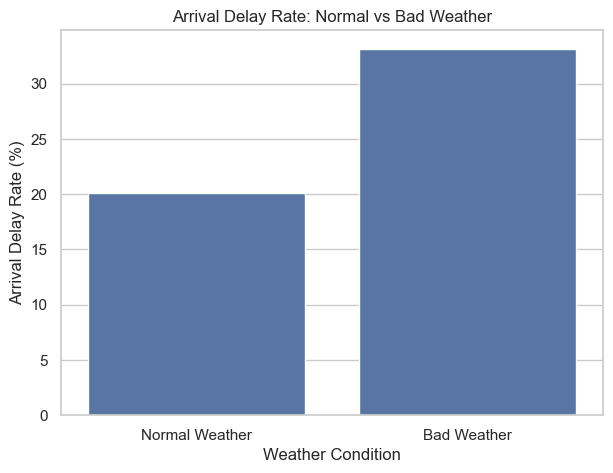

In [98]:
plt.figure(figsize=(7, 5))
sns.barplot(x=bad_weather_delay.index, y=bad_weather_delay.values)
plt.title("Arrival Delay Rate: Normal vs Bad Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Arrival Delay Rate (%)")
plt.show()

## 9.4 Weather vs cancellation

In [99]:
weather_cancellation = (
    df.groupby("bad_weather")["cancelled"]
    .mean()
    .mul(100)
)

weather_cancellation.index = [
    "Normal Weather" if x == 0 else "Bad Weather"
    for x in weather_cancellation.index
]

weather_cancellation

Normal Weather     2.433018
Bad Weather       10.264191
Name: cancelled, dtype: float64

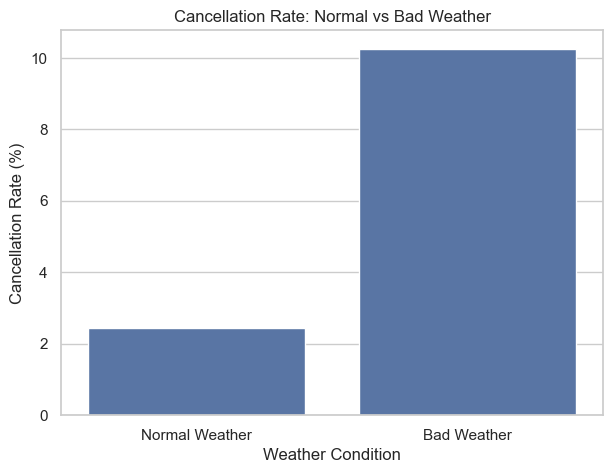

In [100]:
plt.figure(figsize=(7, 5))
sns.barplot(x=weather_cancellation.index, y=weather_cancellation.values)
plt.title("Cancellation Rate: Normal vs Bad Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Cancellation Rate (%)")
plt.show()

## 9.5 Weather vs diversion

In [101]:
weather_diversion = (
    df.groupby("bad_weather")["diverted"]
    .mean()
    .mul(100)
)

weather_diversion.index = [
    "Normal Weather" if x == 0 else "Bad Weather"
    for x in weather_diversion.index
]

weather_diversion

Normal Weather    0.243929
Bad Weather       0.348107
Name: diverted, dtype: float64

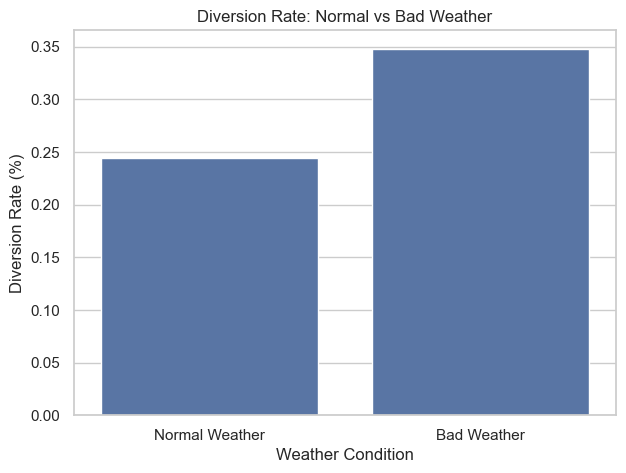

In [102]:
plt.figure(figsize=(7, 5))
sns.barplot(x=weather_diversion.index, y=weather_diversion.values)
plt.title("Diversion Rate: Normal vs Bad Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Diversion Rate (%)")
plt.show()

## 9.6 Weather impact by airport

In [103]:
# Calculate airport-level arrival delay rates under normal and bad weather.
airport_weather = (
    completed_df.groupby(["origin", "bad_weather"])["arr_del15"]
    .mean()
    .mul(100)
    .reset_index()
)

airport_weather_pivot = airport_weather.pivot(
    index="origin",
    columns="bad_weather",
    values="arr_del15"
).rename(columns={0: "Normal_Weather", 1: "Bad_Weather"})

# Add flight volume so small airports can be filtered from the comparison.
airport_counts = completed_df.groupby("origin").size()
airport_weather_pivot["flight_count"] = airport_counts

airport_weather_pivot = airport_weather_pivot[
    airport_weather_pivot["flight_count"] >= 100
]

# Measure the change in delay rate associated with bad weather.
airport_weather_pivot["weather_difference"] = (
    airport_weather_pivot["Bad_Weather"] -
    airport_weather_pivot["Normal_Weather"]
)

airport_weather_pivot.sort_values(
    "weather_difference",
    ascending=False
).head(15)

bad_weather,Normal_Weather,Bad_Weather,flight_count,weather_difference
origin,,,,
SWO,12.345679,75.000000,166,62.654321
ABI,12.837838,71.428571,451,58.590734
PRC,14.843750,66.666667,265,51.822917
RKS,15.384615,66.666667,178,51.282051
PIR,20.714286,66.666667,149,45.952381
PHF,9.935897,54.838710,343,44.902812
HYS,15.972222,60.000000,149,44.027778
SHR,16.564417,60.000000,178,43.435583
DRO,15.690169,58.333333,1067,42.643165


## 9.7 ⭐ Weather impact heatmap

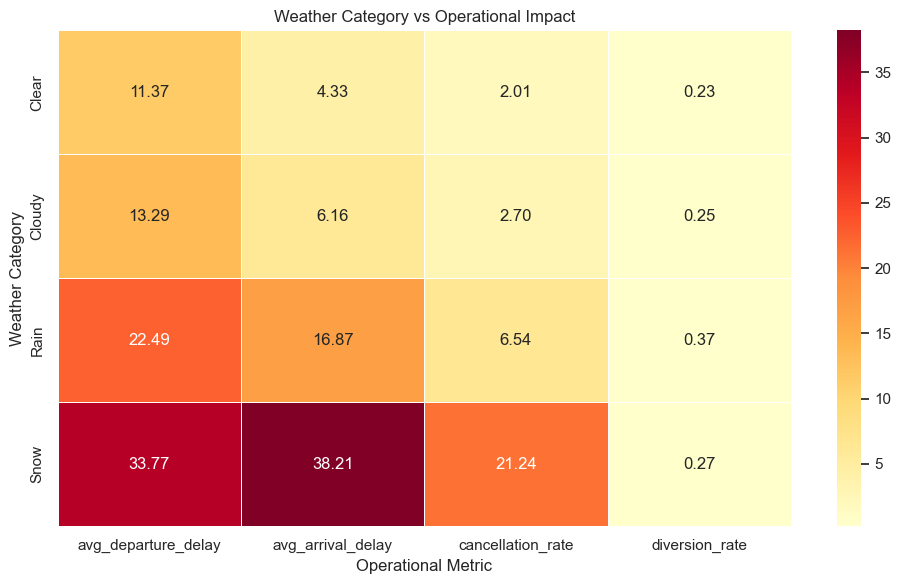

In [104]:
# Build one consolidated table so multiple weather-related outcomes
# can be compared in a single visual.
weather_impact = df.groupby("weather_category").agg(
    flights=("weather_category", "size"),
    avg_departure_delay=("dep_delay", "mean"),
    avg_arrival_delay=("arr_delay", "mean"),
    cancellation_rate=("cancelled", "mean"),
    diversion_rate=("diverted", "mean")
)

# Convert rate metrics to percentages.
weather_impact["cancellation_rate"] *= 100
weather_impact["diversion_rate"] *= 100

# Use the weather categories as rows and operational outcomes as columns.
weather_heatmap_data = weather_impact[
    [
        "avg_departure_delay",
        "avg_arrival_delay",
        "cancellation_rate",
        "diversion_rate"
    ]
].copy()

plt.figure(figsize=(10, 6))
sns.heatmap(
    weather_heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Weather Category vs Operational Impact")
plt.xlabel("Operational Metric")
plt.ylabel("Weather Category")
plt.tight_layout()
plt.show()

## 9.8 Weather observations

In [105]:
# Review basic weather-variable statistics.
print("Average temperature:", round(df["temperature"].mean(), 2))
print("Average precipitation:", round(df["precipitation"].mean(), 2))
print("Average wind speed:", round(df["wind_speed"].mean(), 2))

Average temperature: 8.19
Average precipitation: 0.09
Average wind speed: 10.75


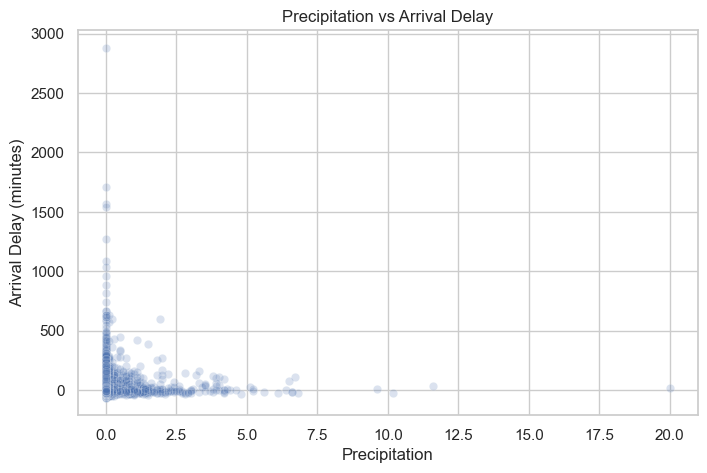

In [106]:
# Examine the relationship between precipitation and arrival delay.
# A sample is used for readability when the dataset is large.
weather_sample = completed_df.sample(
    min(10000, len(completed_df)),
    random_state=42
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=weather_sample,
    x="precipitation",
    y="arr_delay",
    alpha=0.2
)

plt.title("Precipitation vs Arrival Delay")
plt.xlabel("Precipitation")
plt.ylabel("Arrival Delay (minutes)")
plt.show()


## 9.9 Weather × Airline


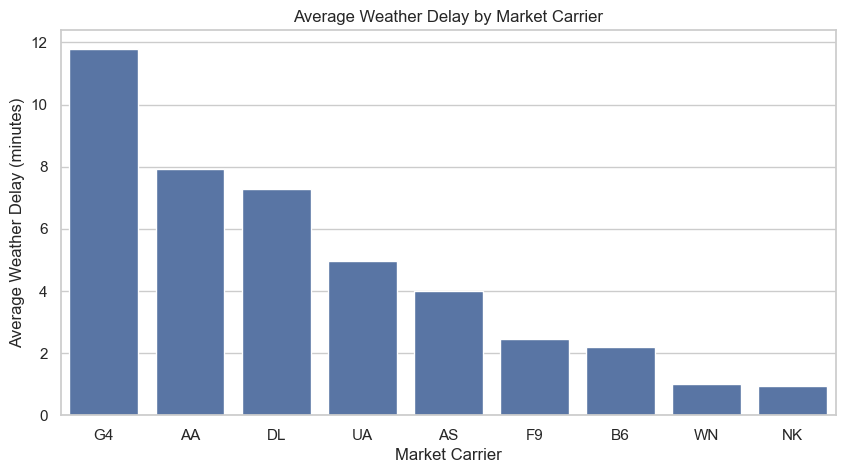

In [107]:

# Weather Impact by Market Carrier or AIrline


weather_carrier = (
    df.groupby('mkt_carrier')['weather_delay']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weather_carrier.index,
    y=weather_carrier.values
)

plt.title('Average Weather Delay by Market Carrier')
plt.xlabel('Market Carrier')
plt.ylabel('Average Weather Delay (minutes)')

plt.show()

## 9.10 Weather × Airport

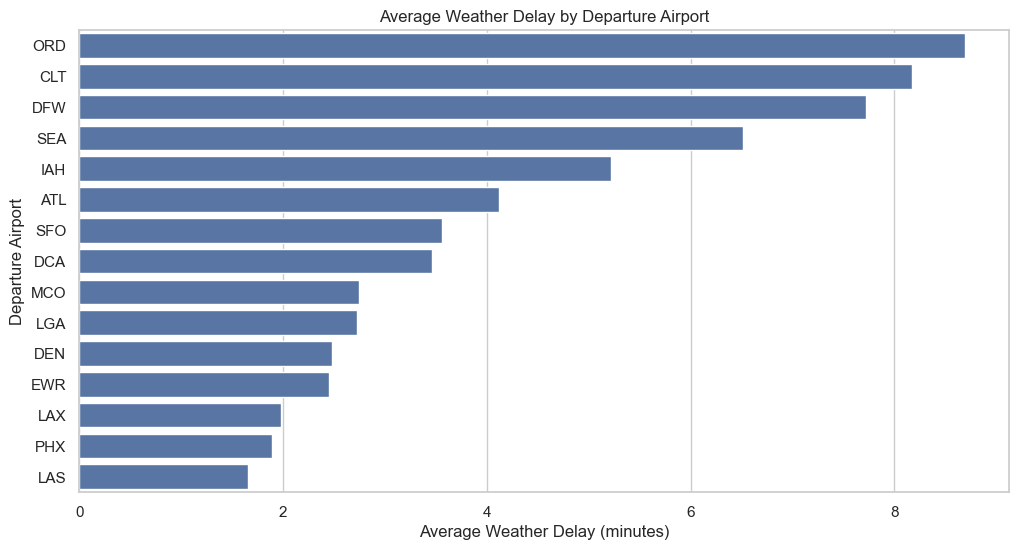

In [108]:

# Weather Impact by Airport


top_airports = df['origin'].value_counts().head(15).index

weather_airport = (
    df[df['origin'].isin(top_airports)]
    .groupby('origin')['weather_delay']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=weather_airport.values,
    y=weather_airport.index
)

plt.title('Average Weather Delay by Departure Airport')
plt.xlabel('Average Weather Delay (minutes)')
plt.ylabel('Departure Airport')

plt.show()

## 9.11 Weather × Month

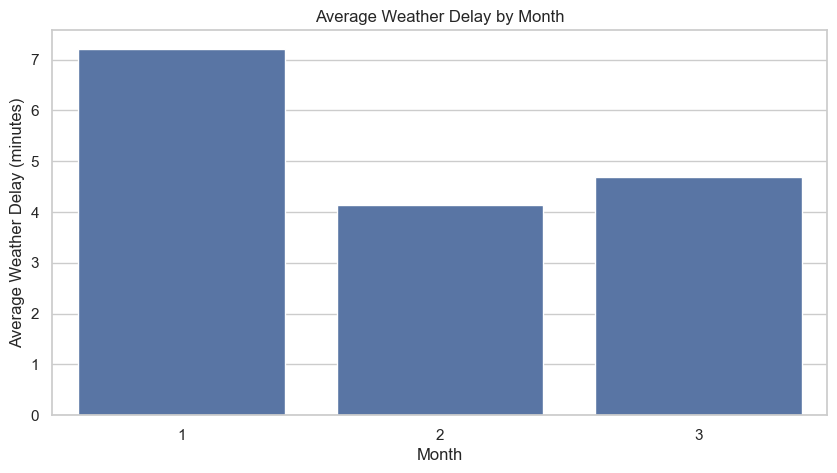

In [109]:
# ============================================================
# Weather Impact by Month
# ============================================================
# Analyze how average weather-related delays change
# across the months in the dataset.
# ============================================================

weather_month = (
    df.groupby('month')['weather_delay']
    .mean()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weather_month.index,
    y=weather_month.values
)

plt.title('Average Weather Delay by Month')
plt.xlabel('Month')
plt.ylabel('Average Weather Delay (minutes)')

plt.show()

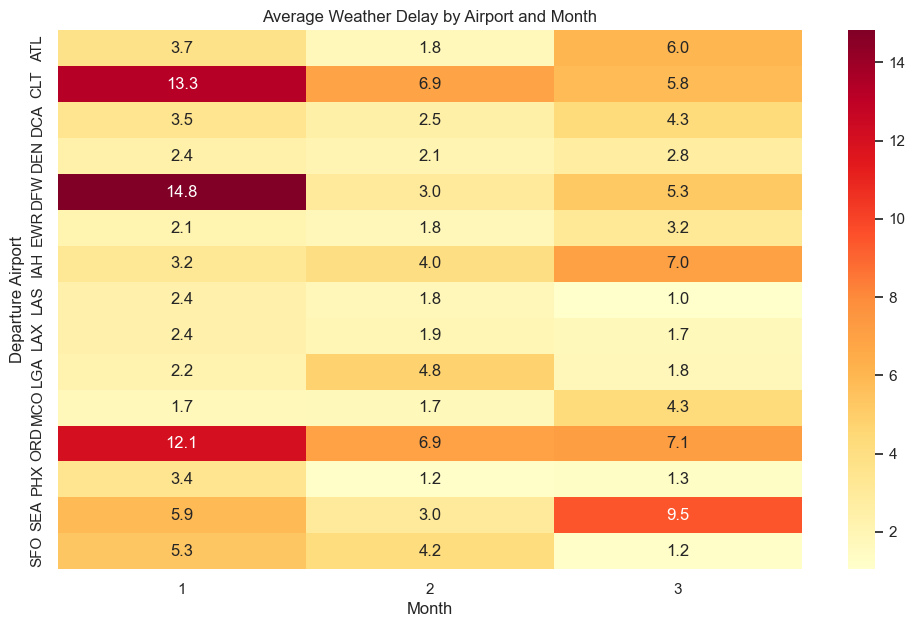

In [110]:

top_airports = df['origin'].value_counts().head(15).index

weather_heatmap = (
    df[df['origin'].isin(top_airports)]
    .pivot_table(
        index='origin',
        columns='month',
        values='weather_delay',
        aggfunc='mean'
    )
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    weather_heatmap,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Average Weather Delay by Airport and Month')
plt.xlabel('Month')
plt.ylabel('Departure Airport')

plt.show()

# 10. KPI Tables for Operational Monitoring

These tables convert the exploratory findings into reusable business-level summaries.

In [111]:
# Airline KPI table.
airline_kpi = df.groupby("mkt_carrier").agg(
    flights=("mkt_carrier", "size"),
    cancelled=("cancelled", "sum"),
    diverted=("diverted", "sum")
)

airline_kpi["cancellation_rate"] = (
    airline_kpi["cancelled"] / airline_kpi["flights"] * 100
).round(2)

airline_delay_kpi = completed_df.groupby("mkt_carrier").agg(
    avg_dep_delay=("dep_delay", "mean"),
    avg_arr_delay=("arr_delay", "mean")
)

airline_kpi = airline_kpi.join(airline_delay_kpi)

airline_kpi["arrival_delay_rate"] = (
    completed_df.groupby("mkt_carrier")["arr_delay"]
    .apply(lambda x: (x >= 15).mean() * 100)
)

airline_kpi.sort_values("flights", ascending=False).head(20)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay,arrival_delay_rate
mkt_carrier,,,,,,,
AA,483902,22945.0,1492.0,4.74,17.090053,10.322157,23.042887
DL,386832,14328.0,840.0,3.70,11.924881,5.853817,20.131893
UA,358108,9204.0,998.0,2.57,12.690776,6.235863,19.804200
WN,327083,5659.0,624.0,1.73,11.368226,3.200954,20.071696
AS,116489,2158.0,386.0,1.85,8.368537,2.175787,18.582650
B6,57320,3010.0,153.0,5.25,19.758351,15.625995,31.207415
F9,50557,1405.0,81.0,2.78,18.359581,13.014408,26.753072
NK,36379,3123.0,55.0,8.58,24.656486,19.661396,35.423632
G4,30572,479.0,108.0,1.57,16.772686,13.490645,24.929131


In [112]:
# Airport KPI table.
airport_kpi = df.groupby("origin").agg(
    flights=("origin", "size"),
    cancelled=("cancelled", "sum"),
    diverted=("diverted", "sum")
)

airport_kpi["cancellation_rate"] = (
    airport_kpi["cancelled"] / airport_kpi["flights"] * 100
).round(2)

airport_delay_kpi = completed_df.groupby("origin").agg(
    avg_dep_delay=("dep_delay", "mean"),
    avg_arr_delay=("arr_delay", "mean")
)

airport_kpi = airport_kpi.join(airport_delay_kpi)
airport_kpi.sort_values("flights", ascending=False).head(20)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay
origin,,,,,,
ORD,88327,3269.0,267.0,3.70,21.624146,17.835183
ATL,82965,2736.0,207.0,3.30,11.645772,8.282797
DEN,74619,1023.0,180.0,1.37,12.343427,4.070897
DFW,72321,3330.0,205.0,4.60,17.136467,10.481290
CLT,55461,3010.0,164.0,5.43,13.322795,5.488075
PHX,51866,682.0,141.0,1.31,11.237976,5.074937
LAX,45488,745.0,139.0,1.64,11.342839,5.032934
MCO,42632,1495.0,92.0,3.51,17.231624,11.412864
LAS,42030,557.0,89.0,1.33,10.851609,3.108109


In [113]:
# Route KPI table.
route_kpi = completed_df.groupby("route").agg(
    flights=("route", "size"),
    avg_arr_delay=("arr_delay", "mean")
)

route_kpi["delay_rate"] = (
    completed_df.groupby("route")["arr_delay"]
    .apply(lambda x: (x >= 15).mean() * 100)
)

route_kpi.sort_values("flights", ascending=False).head(20)

,flights,avg_arr_delay,delay_rate
route,,,
SFO → LAX,2715,3.315285,17.163904
LAX → SFO,2714,3.291083,21.002211
ORD → LGA,2576,15.495342,31.211180
LGA → ORD,2557,14.231521,29.292139
HNL → OGG,2484,8.110306,21.578100
OGG → HNL,2482,9.169218,23.529412
DEN → PHX,2360,3.230932,20.211864
PHX → DEN,2360,7.028390,20.381356
JFK → LAX,2285,0.877024,21.706783


In [114]:
# Routes with the highest delay rate.
route_kpi.sort_values("delay_rate", ascending=False).head(20)

,flights,avg_arr_delay,delay_rate
route,,,
SFB → RIC,1,32.000000,100.0
SFB → LIT,1,125.000000,100.0
FLL → RNO,3,27.333333,100.0
SJU → CLE,4,50.500000,100.0
CLE → SJU,4,37.500000,100.0
OMA → TPA,1,42.000000,100.0
SJU → LGA,1,18.000000,100.0
ELP → MCO,1,38.000000,100.0
SRQ → AUS,1,31.000000,100.0


# 11. Business Questions — Final Checks

Use these outputs to answer the original business questions with evidence rather than assumptions.

### Q1. Which airlines have the highest cancellation rate?

In [115]:
airline_kpi.sort_values("cancellation_rate", ascending=False).head(10)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay,arrival_delay_rate
mkt_carrier,,,,,,,
NK,36379,3123.0,55.0,8.58,24.656486,19.661396,35.423632
B6,57320,3010.0,153.0,5.25,19.758351,15.625995,31.207415
AA,483902,22945.0,1492.0,4.74,17.090053,10.322157,23.042887
DL,386832,14328.0,840.0,3.70,11.924881,5.853817,20.131893
F9,50557,1405.0,81.0,2.78,18.359581,13.014408,26.753072
UA,358108,9204.0,998.0,2.57,12.690776,6.235863,19.804200
AS,116489,2158.0,386.0,1.85,8.368537,2.175787,18.582650
WN,327083,5659.0,624.0,1.73,11.368226,3.200954,20.071696
G4,30572,479.0,108.0,1.57,16.772686,13.490645,24.929131


### Q2. Which airlines have the highest arrival-delay rate?

In [116]:
airline_kpi.sort_values("arrival_delay_rate", ascending=False).head(10)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay,arrival_delay_rate
mkt_carrier,,,,,,,
NK,36379,3123.0,55.0,8.58,24.656486,19.661396,35.423632
B6,57320,3010.0,153.0,5.25,19.758351,15.625995,31.207415
F9,50557,1405.0,81.0,2.78,18.359581,13.014408,26.753072
G4,30572,479.0,108.0,1.57,16.772686,13.490645,24.929131
AA,483902,22945.0,1492.0,4.74,17.090053,10.322157,23.042887
DL,386832,14328.0,840.0,3.70,11.924881,5.853817,20.131893
WN,327083,5659.0,624.0,1.73,11.368226,3.200954,20.071696
UA,358108,9204.0,998.0,2.57,12.690776,6.235863,19.804200
AS,116489,2158.0,386.0,1.85,8.368537,2.175787,18.582650


### Q3. Which airports have the highest average departure delay?

In [117]:
airport_kpi.sort_values("avg_dep_delay", ascending=False).head(15)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay
origin,,,,,,
PAH,72,1.0,0.0,1.39,75.352113,61.521127
ART,180,9.0,1.0,5.00,71.723529,70.388235
JST,179,15.0,1.0,8.38,66.932515,64.889571
MQT,314,36.0,0.0,11.46,57.000000,49.543165
IMT,180,14.0,0.0,7.78,55.807229,47.349398
BGM,45,2.0,0.0,4.44,48.093023,37.813953
LWB,70,7.0,0.0,10.00,47.682540,46.000000
HGR,52,0.0,0.0,0.00,47.346154,38.923077
EAU,153,9.0,0.0,5.88,44.930556,46.076389


### Q4. Which routes have the highest delay rate?

In [118]:
route_kpi.sort_values("delay_rate", ascending=False).head(15)

,flights,avg_arr_delay,delay_rate
route,,,
SFB → RIC,1,32.000000,100.0
SFB → LIT,1,125.000000,100.0
FLL → RNO,3,27.333333,100.0
SJU → CLE,4,50.500000,100.0
CLE → SJU,4,37.500000,100.0
OMA → TPA,1,42.000000,100.0
SJU → LGA,1,18.000000,100.0
ELP → MCO,1,38.000000,100.0
SRQ → AUS,1,31.000000,100.0


### Q5. What is the biggest source of delay?

In [119]:
print("Largest delay cause:", delay_totals.idxmax())
print("Delay minutes:", delay_totals.max())

Largest delay cause: late_aircraft_delay
Delay minutes: 11252035.0


### Q6. Are delays getting worse or better over time?

In [120]:
monthly_avg_arr_delay.diff().tail(12)

fl_date
2026-01         NaN
2026-02   -2.473129
2026-03    6.710676
Freq: M, Name: arr_delay, dtype: float64

### Q7. Do departure delays carry into arrival delays?

In [121]:
corr_value = completed_df[["dep_delay", "arr_delay"]].corr().loc[
    "dep_delay", "arr_delay"
]
print("Correlation:", round(corr_value, 2))

Correlation: 0.97


# ✅ EDA COMPLETE

The cleaned dataset has been explored through:
- Data quality validation
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Outlier investigation
- Delay-cause analysis
- Airline, airport, and route performance
- Cancellation and diversion analysis
- Time-based operational analysis
- Weather impact analysis
- Weather heatmap
- Correlation heatmap
- KPI tables
- Business-question validation

